# German Electricity Load Forecasting

## Objective

This notebook prepares the German electricity dataset for short-term
electricity demand forecasting.

We will:

1. Load and preserve the original dataset
2. Validate timestamps and data structure
3. Explore electricity demand and missing periods
4. Identify suspicious or corrupted observations
5. Clean the dataset
6. Create continuous time-series segments
7. Engineer lag and calendar features
8. Prepare the final modelling dataset
9. Perform a chronological train/test split
10. Train and evaluate forecasting models

### Important data-handling rule

`df_raw` will always remain an untouched copy of the original CSV.

All cleaning operations will be performed on `df`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# 1. Load the Original Dataset

We first load the CSV exactly as provided.

No cleaning, filtering, interpolation, or feature engineering is performed
at this stage.

In [2]:
file_path = r"C:\Users\Grace\OneDrive\Documents\Colleye TY\5th Semester\GridAI\data\power_consumption_germany.csv"

df_raw = pd.read_csv(file_path)

print("Original dataset loaded successfully.")
print("Shape:", df_raw.shape)

Original dataset loaded successfully.
Shape: (395375, 88)


## 2. Verify the Original Dataset

Before performing any cleaning or transformation, we inspect the original
dataset to understand its structure, data types, columns, timestamps, and
potential data-quality issues.

The original `df_raw` dataframe will remain unchanged.

In [3]:
print("Dataset shape:", df_raw.shape)

print("\nNumber of rows:", len(df_raw))
print("Number of columns:", len(df_raw.columns))

print("\nColumn names:")
print(df_raw.columns.tolist())

Dataset shape: (395375, 88)

Number of rows: 395375
Number of columns: 88

Column names:
['Unnamed: 0', 'load_Actual Load', 'wind_and_solar_forecast_Solar', 'wind_and_solar_forecast_Wind Offshore', 'wind_and_solar_forecast_Wind Onshore', 'intraday_wind_and_solar_forecast_Solar', 'intraday_wind_and_solar_forecast_Wind Offshore', 'intraday_wind_and_solar_forecast_Wind Onshore', 'generation_Biomass_Actual Aggregated', 'generation_Biomass_Actual Consumption', 'generation_Fossil Brown coal/Lignite_Actual Aggregated', 'generation_Fossil Brown coal/Lignite_Actual Consumption', 'generation_Fossil Coal-derived gas_Actual Aggregated', 'generation_Fossil Coal-derived gas_Actual Consumption', 'generation_Fossil Gas_Actual Aggregated', 'generation_Fossil Gas_Actual Consumption', 'generation_Fossil Hard coal_Actual Aggregated', 'generation_Fossil Hard coal_Actual Consumption', 'generation_Fossil Oil_Actual Aggregated', 'generation_Fossil Oil_Actual Consumption', 'generation_Geothermal_Actual Aggrega

In [4]:
print("First 5 rows:")
display(df_raw.head())

print("\nLast 5 rows:")
display(df_raw.tail())

First 5 rows:


,Unnamed: 0,load_Actual Load,wind_and_solar_forecast_Solar,wind_and_solar_forecast_Wind Offshore,wind_and_solar_forecast_Wind Onshore,intraday_wind_and_solar_forecast_Solar,intraday_wind_and_solar_forecast_Wind Offshore,intraday_wind_and_solar_forecast_Wind Onshore,generation_Biomass_Actual Aggregated,generation_Biomass_Actual Consumption,generation_Fossil Brown coal/Lignite_Actual Aggregated,generation_Fossil Brown coal/Lignite_Actual Consumption,generation_Fossil Coal-derived gas_Actual Aggregated,generation_Fossil Coal-derived gas_Actual Consumption,generation_Fossil Gas_Actual Aggregated,generation_Fossil Gas_Actual Consumption,generation_Fossil Hard coal_Actual Aggregated,generation_Fossil Hard coal_Actual Consumption,generation_Fossil Oil_Actual Aggregated,generation_Fossil Oil_Actual Consumption,generation_Geothermal_Actual Aggregated,generation_Geothermal_Actual Consumption,generation_Hydro Pumped Storage_Actual Aggregated,generation_Hydro Pumped Storage_Actual Consumption,generation_Hydro Run-of-river and poundage_Actual Aggregated,generation_Hydro Run-of-river and poundage_Actual Consumption,generation_Hydro Water Reservoir_Actual Aggregated,generation_Hydro Water Reservoir_Actual Consumption,generation_Nuclear_Actual Aggregated,generation_Nuclear_Actual Consumption,generation_Other_Actual Aggregated,generation_Other_Actual Consumption,generation_Other renewable_Actual Aggregated,generation_Other renewable_Actual Consumption,generation_Solar_Actual Aggregated,generation_Solar_Actual Consumption,generation_Waste_Actual Aggregated,generation_Waste_Actual Consumption,generation_Wind Offshore_Actual Aggregated,generation_Wind Onshore_Actual Aggregated,generation_Wind Onshore_Actual Consumption,import_CH,import_CZ,import_DK_1,import_DK_2,import_FR,import_IT_NORD,import_IT_NORD_AT,import_NL,import_PL,import_SE_4,import_SI,import_sum,generation_import_Generation_Biomass,generation_import_Generation_Fossil Brown coal/Lignite,generation_import_Generation_Fossil Coal-derived gas,generation_import_Generation_Fossil Gas,generation_import_Generation_Fossil Hard coal,generation_import_Generation_Fossil Oil,generation_import_Generation_Geothermal,generation_import_Generation_Hydro Pumped Storage,generation_import_Generation_Hydro Run-of-river and poundage,generation_import_Generation_Hydro Water Reservoir,generation_import_Generation_Nuclear,generation_import_Generation_Other,generation_import_Generation_Other renewable,generation_import_Generation_Solar,generation_import_Generation_Waste,generation_import_Generation_Wind Offshore,generation_import_Generation_Wind Onshore,generation_import_Import_CH,generation_import_Import_CZ,generation_import_Import_DK_1,generation_import_Import_DK_2,generation_import_Import_FR,generation_import_Import_IT_NORD,generation_import_Import_IT_NORD_AT,generation_import_Import_NL,generation_import_Import_PL,generation_import_Import_SE_4,generation_import_Import_SI,generation_import_Import_sum,import_BE,generation_import_Import_BE,import_AT,generation_import_Import_AT,import_NO_2,generation_import_Import_NO_2
0,2015-01-01 00:00:00+01:00,51873.64,0.0,258.0,7517.70,0.0,219.0,3713.0,5014.84,0.0,15858.61,0.0,0.0,0.0,2303.69,0.0,3237.13,0.0,177.00,4.53,13.18,0.0,640.34,909.99,2704.93,0.0,319.50,0.0,10742.46,0.0,536.38,0.0,226.32,0.0,0.15,0.0,306.73,0.0,524.39,8866.33,0.0,NaN,3001.04,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,3001.04,5014.84,15858.61,0.0,2303.69,3237.13,172.47,13.18,-269.65,2704.93,319.50,10742.46,536.38,226.32,0.15,306.73,524.39,8866.33,NaN,3001.04,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,3001.04,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01 00:15:00+01:00,51382.96,0.0,258.0,7603.26,0.0,219.0,3789.0,5020.28,0.0,15803.40,0.0,0.0,0.0,2289.32,0.0,3347.26,0.0,176.57,4.46,13.13,0.0,661.03,1066.55,2687.53,0.0,265.49,0.0,10585.00,0.0,537.33,0.0,226.02,0.0,0.15,0.0,308.84,0.0,521.40,8867.96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5020.28,15803.40,0.0,2289.32,3347.26,172.11,13.13,-405.52,2687.53,265.49,10585.0


Last 5 rows:


,Unnamed: 0,load_Actual Load,wind_and_solar_forecast_Solar,wind_and_solar_forecast_Wind Offshore,wind_and_solar_forecast_Wind Onshore,intraday_wind_and_solar_forecast_Solar,intraday_wind_and_solar_forecast_Wind Offshore,intraday_wind_and_solar_forecast_Wind Onshore,generation_Biomass_Actual Aggregated,generation_Biomass_Actual Consumption,generation_Fossil Brown coal/Lignite_Actual Aggregated,generation_Fossil Brown coal/Lignite_Actual Consumption,generation_Fossil Coal-derived gas_Actual Aggregated,generation_Fossil Coal-derived gas_Actual Consumption,generation_Fossil Gas_Actual Aggregated,generation_Fossil Gas_Actual Consumption,generation_Fossil Hard coal_Actual Aggregated,generation_Fossil Hard coal_Actual Consumption,generation_Fossil Oil_Actual Aggregated,generation_Fossil Oil_Actual Consumption,generation_Geothermal_Actual Aggregated,generation_Geothermal_Actual Consumption,generation_Hydro Pumped Storage_Actual Aggregated,generation_Hydro Pumped Storage_Actual Consumption,generation_Hydro Run-of-river and poundage_Actual Aggregated,generation_Hydro Run-of-river and poundage_Actual Consumption,generation_Hydro Water Reservoir_Actual Aggregated,generation_Hydro Water Reservoir_Actual Consumption,generation_Nuclear_Actual Aggregated,generation_Nuclear_Actual Consumption,generation_Other_Actual Aggregated,generation_Other_Actual Consumption,generation_Other renewable_Actual Aggregated,generation_Other renewable_Actual Consumption,generation_Solar_Actual Aggregated,generation_Solar_Actual Consumption,generation_Waste_Actual Aggregated,generation_Waste_Actual Consumption,generation_Wind Offshore_Actual Aggregated,generation_Wind Onshore_Actual Aggregated,generation_Wind Onshore_Actual Consumption,import_CH,import_CZ,import_DK_1,import_DK_2,import_FR,import_IT_NORD,import_IT_NORD_AT,import_NL,import_PL,import_SE_4,import_SI,import_sum,generation_import_Generation_Biomass,generation_import_Generation_Fossil Brown coal/Lignite,generation_import_Generation_Fossil Coal-derived gas,generation_import_Generation_Fossil Gas,generation_import_Generation_Fossil Hard coal,generation_import_Generation_Fossil Oil,generation_import_Generation_Geothermal,generation_import_Generation_Hydro Pumped Storage,generation_import_Generation_Hydro Run-of-river and poundage,generation_import_Generation_Hydro Water Reservoir,generation_import_Generation_Nuclear,generation_import_Generation_Other,generation_import_Generation_Other renewable,generation_import_Generation_Solar,generation_import_Generation_Waste,generation_import_Generation_Wind Offshore,generation_import_Generation_Wind Onshore,generation_import_Import_CH,generation_import_Import_CZ,generation_import_Import_DK_1,generation_import_Import_DK_2,generation_import_Import_FR,generation_import_Import_IT_NORD,generation_import_Import_IT_NORD_AT,generation_import_Import_NL,generation_import_Import_PL,generation_import_Import_SE_4,generation_import_Import_SI,generation_import_Import_sum,import_BE,generation_import_Import_BE,import_AT,generation_import_Import_AT,import_NO_2,generation_import_Import_NO_2
395370,2026-08-28 22:45:00+02:00,NaN,NaN,NaN,NaN,0.0,5504.57,18274.98256,4085.48873,NaN,8052.49335,NaN,399.71099,NaN,3177.96539,NaN,3169.77860,NaN,377.60200,NaN,19.24709,NaN,205.0986,607.2183,1306.93968,NaN,27.9993,NaN,NaN,NaN,137.17643,NaN,70.451,NaN,0.154,NaN,901.1467,NaN,6459.038,20723.86459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395371,2026-08-28 23:00:00+02:00,NaN,NaN,NaN,NaN,0.0,5613.81,18485.37804,4001.24103,NaN,7792.63672,NaN,398.67366,NaN,3086.72544,NaN,2918.74576,NaN,378.80867,NaN,19.24709,NaN,688.1687,70.3451,1297.02358,NaN,142.0224,NaN,NaN,NaN,137.17643,NaN,70.451,NaN,0.147,NaN,903.8097,NaN,6020.527,20415.38387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
print("Data types:")
display(df_raw.dtypes)

Data types:


Unnamed: 0                                                        object
load_Actual Load                                                 float64
wind_and_solar_forecast_Solar                                    float64
wind_and_solar_forecast_Wind Offshore                            float64
wind_and_solar_forecast_Wind Onshore                             float64
intraday_wind_and_solar_forecast_Solar                           float64
intraday_wind_and_solar_forecast_Wind Offshore                   float64
intraday_wind_and_solar_forecast_Wind Onshore                    float64
generation_Biomass_Actual Aggregated                             float64
generation_Biomass_Actual Consumption                            float64
generation_Fossil Brown coal/Lignite_Actual Aggregated           float64
generation_Fossil Brown coal/Lignite_Actual Consumption          float64
generation_Fossil Coal-derived gas_Actual Aggregated             float64
generation_Fossil Coal-derived gas_Actual Consumpti

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395375 entries, 0 to 395374
Data columns (total 88 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   Unnamed: 0                                                     395375 non-null  object 
 1   load_Actual Load                                               395179 non-null  float64
 2   wind_and_solar_forecast_Solar                                  395267 non-null  float64
 3   wind_and_solar_forecast_Wind Offshore                          395183 non-null  float64
 4   wind_and_solar_forecast_Wind Onshore                           395267 non-null  float64
 5   intraday_wind_and_solar_forecast_Solar                         395087 non-null  float64
 6   intraday_wind_and_solar_forecast_Wind Offshore                 395375 non-null  float64
 7   intraday_wind_and_solar_forecast_Wind Onshore  

# 3. Timestamp and Data Continuity Exploration

The dataset contains a timestamp column stored under `Unnamed: 0`.

In this section, we will:

1. Convert the timestamp into a proper datetime representation.
2. Check the chronological range of the dataset.
3. Check whether timestamps are duplicated.
4. Check the expected 15-minute sampling interval.
5. Identify genuine gaps in the time series.
6. Determine whether the apparent missing period near the end of the dataset is actually missing data or simply rows with unavailable measurements.

No observations will be deleted in this section.

In [7]:
df = df_raw.copy()

print("Working dataframe created.")
print("Shape:", df.shape)

Working dataframe created.
Shape: (395375, 88)


In [8]:
df = df.rename(columns={"Unnamed: 0": "timestamp"})

print("Timestamp column renamed successfully.")
print("First columns:")
print(df.columns[:10].tolist())

Timestamp column renamed successfully.
First columns:
['timestamp', 'load_Actual Load', 'wind_and_solar_forecast_Solar', 'wind_and_solar_forecast_Wind Offshore', 'wind_and_solar_forecast_Wind Onshore', 'intraday_wind_and_solar_forecast_Solar', 'intraday_wind_and_solar_forecast_Wind Offshore', 'intraday_wind_and_solar_forecast_Wind Onshore', 'generation_Biomass_Actual Aggregated', 'generation_Biomass_Actual Consumption']


In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print("Timestamp conversion completed.")
print("Timestamp dtype:", df["timestamp"].dtype)

Timestamp conversion completed.
Timestamp dtype: datetime64[ns, UTC]


In [10]:
print("Earliest timestamp:", df["timestamp"].min())
print("Latest timestamp:", df["timestamp"].max())
print("Total observations:", len(df))

Earliest timestamp: 2014-12-31 23:00:00+00:00
Latest timestamp: 2026-08-28 21:45:00+00:00
Total observations: 395375


In [11]:
duplicate_timestamps = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [12]:
is_sorted = df["timestamp"].is_monotonic_increasing

print("Timestamps already sorted:", is_sorted)

Timestamps already sorted: True


In [13]:
df = df.sort_values("timestamp").reset_index(drop=True)

print("Data sorted chronologically.")
print("First timestamp:", df["timestamp"].iloc[0])
print("Last timestamp:", df["timestamp"].iloc[-1])

Data sorted chronologically.
First timestamp: 2014-12-31 23:00:00+00:00
Last timestamp: 2026-08-28 21:45:00+00:00


In [14]:
df["time_gap"] = df["timestamp"].diff()

print("Most common timestamp gaps:")
display(df["time_gap"].value_counts().head(10))

Most common timestamp gaps:


time_gap
0 days 00:15:00     395324
0 days 23:30:00         48
92 days 01:15:00         1
0 days 22:30:00          1
Name: count, dtype: int64

In [15]:
large_gaps = df.loc[
    df["time_gap"] > pd.Timedelta(hours=1),
    ["timestamp", "time_gap"]
]

display(large_gaps)

,timestamp,time_gap
34947,2015-12-31 23:00:00+00:00,0 days 23:30:00
69990,2016-12-31 23:00:00+00:00,0 days 23:30:00
104937,2017-12-31 23:00:00+00:00,0 days 23:30:00
131141,2018-12-31 23:00:00+00:00,92 days 01:15:00
166088,2019-12-31 23:00:00+00:00,0 days 23:30:00
201131,2020-12-31 23:00:00+00:00,0 days 23:30:00
236078,2021-12-31 23:00:00+00:00,0 days 23:30:00
271025,2022-12-31 23:00:00+00:00,0 days 23:30:00
305972,2023-12-31 23:00:00+00:00,0 days 23:30:00
341015,2024-12-31 23:00:00+00:00,0 days 23:30:00


In [16]:
gap_start = pd.Timestamp("2018-09-30 21:45:00", tz="UTC")
gap_end = pd.Timestamp("2018-12-31 23:00:00", tz="UTC")

print("Rows around the 2018 gap:")

display(
    df[
        df["timestamp"].between(
            gap_start - pd.Timedelta(hours=1),
            gap_end + pd.Timedelta(hours=1)
        )
    ][["timestamp", "load_Actual Load"]]
)

Rows around the 2018 gap:


,timestamp,load_Actual Load
131136,2018-09-30 20:45:00+00:00,53242.50
131137,2018-09-30 21:00:00+00:00,52566.48
131138,2018-09-30 21:15:00+00:00,51902.71
131139,2018-09-30 21:30:00+00:00,50895.16
131140,2018-09-30 21:45:00+00:00,50136.52
131141,2018-12-31 23:00:00+00:00,44461.48
131142,2018-12-31 23:15:00+00:00,43913.65
131143,2018-12-31 23:30:00+00:00,43380.86
131144,2018-12-31 23:45:00+00:00,43131.04
131145,2019-01-01 00:00:00+00:00,42824.86


In [17]:
expected_timestamps = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="15min",
    tz="UTC"
)

actual_timestamps = pd.DatetimeIndex(df["timestamp"])

missing_timestamps = expected_timestamps.difference(actual_timestamps)

print("Expected timestamps:", len(expected_timestamps))
print("Actual timestamps:", len(actual_timestamps))
print("Missing timestamps:", len(missing_timestamps))

Expected timestamps: 408764
Actual timestamps: 395375
Missing timestamps: 13389


In [18]:
if len(missing_timestamps) > 0:
    missing_series = pd.Series(missing_timestamps)

    missing_groups = (
        missing_series.diff() != pd.Timedelta(minutes=15)
    ).cumsum()

    missing_periods = missing_series.groupby(missing_groups).agg(
        start="min",
        end="max",
        count="size"
    )

    missing_periods["duration"] = (
        missing_periods["end"]
        - missing_periods["start"]
        + pd.Timedelta(minutes=15)
    )

    display(missing_periods)
else:
    print("No missing timestamps found.")

,start,end,count,duration
1,2015-12-30 23:45:00+00:00,2015-12-31 22:45:00+00:00,93,0 days 23:15:00
2,2016-12-30 23:45:00+00:00,2016-12-31 22:45:00+00:00,93,0 days 23:15:00
3,2017-12-30 23:45:00+00:00,2017-12-31 22:45:00+00:00,93,0 days 23:15:00
4,2018-09-30 22:00:00+00:00,2018-12-31 22:45:00+00:00,8836,92 days 01:00:00
5,2019-12-30 23:45:00+00:00,2019-12-31 22:45:00+00:00,93,0 days 23:15:00
6,2020-12-30 23:45:00+00:00,2020-12-31 22:45:00+00:00,93,0 days 23:15:00
7,2021-12-30 23:45:00+00:00,2021-12-31 22:45:00+00:00,93,0 days 23:15:00
8,2022-12-30 23:45:00+00:00,2022-12-31 22:45:00+00:00,93,0 days 23:15:00
9,2023-12-30 23:45:00+00:00,2023-12-31 22:45:00+00:00,93,0 days 23:15:00
10,2024-12-30 23:45:00+00:00,2024-12-31 22:45:00+00:00,93,0 days 23:15:00


In [19]:
print("First 10 ORIGINAL timestamp values:")
display(df_raw["Unnamed: 0"].head(10))

print("\nLast 10 ORIGINAL timestamp values:")
display(df_raw["Unnamed: 0"].tail(10))

First 10 ORIGINAL timestamp values:


0    2015-01-01 00:00:00+01:00
1    2015-01-01 00:15:00+01:00
2    2015-01-01 00:30:00+01:00
3    2015-01-01 00:45:00+01:00
4    2015-01-01 01:00:00+01:00
5    2015-01-01 01:15:00+01:00
6    2015-01-01 01:30:00+01:00
7    2015-01-01 01:45:00+01:00
8    2015-01-01 02:00:00+01:00
9    2015-01-01 02:15:00+01:00
Name: Unnamed: 0, dtype: object


Last 10 ORIGINAL timestamp values:


395365    2026-08-28 21:30:00+02:00
395366    2026-08-28 21:45:00+02:00
395367    2026-08-28 22:00:00+02:00
395368    2026-08-28 22:15:00+02:00
395369    2026-08-28 22:30:00+02:00
395370    2026-08-28 22:45:00+02:00
395371    2026-08-28 23:00:00+02:00
395372    2026-08-28 23:15:00+02:00
395373    2026-08-28 23:30:00+02:00
395374    2026-08-28 23:45:00+02:00
Name: Unnamed: 0, dtype: object

# 4. Missing Value Analysis

The timestamp structure and chronological ordering have been verified.

We now examine missing values in the measurement variables. This step only
quantifies missing data; no values or rows will be modified yet.

The timestamp column is excluded because it represents the time index rather
than a measurement.

In [20]:
# Identify measurement columns
measurement_columns = [
    col for col in df.columns
    if col not in ["timestamp", "time_gap"]
]

# Calculate missing values
missing_summary = pd.DataFrame({
    "missing_count": df[measurement_columns].isna().sum(),
    "missing_percentage": (
        df[measurement_columns].isna().mean() * 100
    ).round(2)
})

# Sort by percentage of missing values
missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
import_IT_NORD,370197,93.63
import_IT_NORD_AT,369869,93.55
import_SI,362589,91.71
generation_Fossil Coal-derived gas_Actual Consumption,290733,73.53
generation_import_Import_IT_NORD_AT,290438,73.46
generation_Fossil Brown coal/Lignite_Actual Consumption,290438,73.46
generation_Nuclear_Actual Consumption,286436,72.45
import_SE_4,284967,72.08
generation_Waste_Actual Consumption,264330,66.86
generation_Other renewable_Actual Consumption,264329,66.86


## Missing Value Analysis Complete

The table above shows the number and percentage of missing observations
for each measurement variable.

No missing values have been filled, interpolated, or deleted at this stage.

The missing-data patterns will be used to determine the appropriate
cleaning strategy for each type of variable.

In [21]:
# Keep only the original measurement variables
measurement_columns = [
    col for col in df.columns
    if col not in ["timestamp", "timestamp_local", "time_gap", "local_time_gap"]
]

# Recalculate missing-value summary
missing_summary = pd.DataFrame({
    "missing_count": df[measurement_columns].isna().sum(),
    "missing_percentage": (
        df[measurement_columns].isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
import_IT_NORD,370197,93.63
import_IT_NORD_AT,369869,93.55
import_SI,362589,91.71
generation_Fossil Coal-derived gas_Actual Consumption,290733,73.53
generation_import_Import_IT_NORD_AT,290438,73.46
generation_Fossil Brown coal/Lignite_Actual Consumption,290438,73.46
generation_Nuclear_Actual Consumption,286436,72.45
import_SE_4,284967,72.08
generation_Waste_Actual Consumption,264330,66.86
generation_Other renewable_Actual Consumption,264329,66.86


# 5. Missingness Pattern Classification

The missing-value analysis shows that missingness is not uniform across
the dataset.

Some variables have very high levels of missing data, while others have
only a small number of missing observations.

Instead of applying one imputation method to every variable, the variables
will first be classified according to their missing-data percentage.

This prevents inappropriate interpolation of variables that contain large
historical periods where the measurement was not available.

In [22]:
# Classify variables according to their percentage of missing values

def classify_missingness(pct):
    if pct == 0:
        return "No missing values"
    elif pct <= 1:
        return "Very low (<=1%)"
    elif pct <= 5:
        return "Low (1-5%)"
    elif pct <= 50:
        return "Moderate (5-50%)"
    else:
        return "High (>50%)"

missing_summary["missing_category"] = (
    missing_summary["missing_percentage"]
    .apply(classify_missingness)
)

display(missing_summary)

,missing_count,missing_percentage,missing_category
import_IT_NORD,370197,93.63,High (>50%)
import_IT_NORD_AT,369869,93.55,High (>50%)
import_SI,362589,91.71,High (>50%)
generation_Fossil Coal-derived gas_Actual Consumption,290733,73.53,High (>50%)
generation_import_Import_IT_NORD_AT,290438,73.46,High (>50%)
generation_Fossil Brown coal/Lignite_Actual Consumption,290438,73.46,High (>50%)
generation_Nuclear_Actual Consumption,286436,72.45,High (>50%)
import_SE_4,284967,72.08,High (>50%)
generation_Waste_Actual Consumption,264330,66.86,High (>50%)
generation_Other renewable_Actual Consumption,264329,66.86,High (>50%)


In [23]:
# Summary of missingness categories

missing_category_counts = (
    missing_summary["missing_category"]
    .value_counts()
)

display(missing_category_counts.to_frame("number_of_variables"))

,number_of_variables
missing_category,
Very low (<=1%),42
High (>50%),24
Moderate (5-50%),16
No missing values,4
Low (1-5%),1


# Missingness Classification Complete

The variables have now been classified according to the proportion of
missing observations.

No rows or columns have been deleted, and no missing values have been
filled.

Variables with substantial missingness will be examined before deciding
whether they should be removed or retained. Variables with small gaps may
be suitable for time-series interpolation, subject to their role in the
forecasting model.

In [24]:
# Display variables in each missingness category

for category in [
    "No missing values",
    "Very low (<=1%)",
    "Low (1-5%)",
    "Moderate (5-50%)",
    "High (>50%)"
]:
    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)
    
    cols = missing_summary[
        missing_summary["missing_category"] == category
    ].index.tolist()
    
    for col in cols:
        print(col)


No missing values
generation_Geothermal_Actual Aggregated
generation_Fossil Brown coal/Lignite_Actual Aggregated
intraday_wind_and_solar_forecast_Wind Offshore
generation_Wind Offshore_Actual Aggregated

Very low (<=1%)
generation_import_Import_PL
generation_import_Import_CH
generation_import_Generation_Other renewable
generation_Other renewable_Actual Aggregated
generation_import_Import_NL
generation_import_Import_FR
generation_import_Generation_Hydro Water Reservoir
generation_Hydro Pumped Storage_Actual Aggregated
generation_Hydro Pumped Storage_Actual Consumption
intraday_wind_and_solar_forecast_Wind Onshore
generation_Hydro Water Reservoir_Actual Aggregated
intraday_wind_and_solar_forecast_Solar
generation_Solar_Actual Aggregated
generation_import_Import_DK_1
generation_Wind Onshore_Actual Aggregated
generation_import_Generation_Fossil Hard coal
generation_import_Generation_Fossil Oil
generation_import_Generation_Fossil Gas
generation_import_Import_CZ
generation_import_Generation

# 6. Missing Data Strategy

The missing-data analysis shows that the dataset contains several distinct
missingness patterns.

Variables with very low missingness are generally suitable for time-series
interpolation because only a small number of observations are unavailable.

Variables with moderate missingness require greater care because large gaps
may make interpolation unreliable.

Variables with more than 50% missing observations will not be blindly
interpolated. Their usefulness will first be evaluated based on their
coverage and role in the forecasting problem.

The target variable, `load_Actual Load`, has only a very small proportion of
missing observations and will be treated separately from predictor variables.

No observations are deleted at this stage.

In [25]:
# Check missing values in the target variable

target_column = "load_Actual Load"

print("Target variable:", target_column)
print("Missing values:", df[target_column].isna().sum())
print(
    "Missing percentage:",
    round(df[target_column].isna().mean() * 100, 2),
    "%"
)

Target variable: load_Actual Load
Missing values: 196
Missing percentage: 0.05 %


# 7. Data Cleaning

Based on the missing-value analysis, the dataset contains variables with
very different levels of data availability.

The following cleaning strategy is adopted:

1. Variables with more than 5% missing values will be removed because
   large missing periods cannot be reliably reconstructed through
   interpolation.

2. Variables with 5% or less missing values will be retained.

3. Small missing gaps in retained predictor variables will be filled using
   time-based interpolation.

4. Rows where the target variable (`load_Actual Load`) is missing will
   not be artificially generated. These rows will be removed from the
   final modelling dataset.

5. The original dataframe (`df_raw`) will remain unchanged throughout
   the cleaning process.

This approach avoids creating artificial long-term data while preserving
variables with sufficiently reliable coverage.

In [26]:
# Define the target
target_column = "load_Actual Load"

# Keep variables with at most 5% missing values
columns_to_keep = missing_summary[
    missing_summary["missing_percentage"] <= 5
].index.tolist()

# Columns with more than 5% missing values will be removed
columns_to_remove = missing_summary[
    missing_summary["missing_percentage"] > 5
].index.tolist()

print("Number of measurement columns:", len(measurement_columns))
print("Columns retained:", len(columns_to_keep))
print("Columns removed:", len(columns_to_remove))

print("\nColumns removed because of >5% missingness:")
for col in columns_to_remove:
    print("-", col)

Number of measurement columns: 87
Columns retained: 47
Columns removed: 40

Columns removed because of >5% missingness:
- import_IT_NORD
- import_IT_NORD_AT
- import_SI
- generation_Fossil Coal-derived gas_Actual Consumption
- generation_import_Import_IT_NORD_AT
- generation_Fossil Brown coal/Lignite_Actual Consumption
- generation_Nuclear_Actual Consumption
- import_SE_4
- generation_Waste_Actual Consumption
- generation_Other renewable_Actual Consumption
- generation_Biomass_Actual Consumption
- generation_Hydro Run-of-river and poundage_Actual Consumption
- generation_import_Import_IT_NORD
- generation_import_Import_SI
- generation_Other_Actual Consumption
- generation_Fossil Hard coal_Actual Consumption
- generation_Geothermal_Actual Consumption
- generation_Hydro Water Reservoir_Actual Consumption
- import_FR
- import_CZ
- import_PL
- generation_Fossil Gas_Actual Consumption
- generation_Fossil Oil_Actual Consumption
- import_AT
- import_NO_2
- generation_import_Import_NO_2
- impo

In [27]:
# Create cleaned dataframe
df_clean = df.copy()

# Remove variables with excessive missingness
df_clean = df_clean.drop(columns=columns_to_remove)

print("Columns removed successfully.")
print("New shape:", df_clean.shape)

Columns removed successfully.
New shape: (395375, 49)


# 8. Interpolation of Small Missing Gaps

The retained predictor variables contain only small amounts of missing data.

Because the dataset is a time series with observations every 15 minutes,
short missing gaps can be estimated using time-based interpolation.

Interpolation is performed only for retained measurement variables and
does not affect the original dataset.

The target variable is handled separately to avoid creating artificial
target observations for model training. 

In [28]:
# Check remaining missing values

remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")

if len(remaining_missing) == 0:
    print("None. All retained variables are complete.")
else:
    display(
        remaining_missing
        .sort_values(ascending=False)
        .to_frame("missing_count")
    )

Remaining missing values:


,missing_count
generation_import_Import_SE_4,9627
generation_import_Import_PL,1119
generation_import_Generation_Other renewable,678
generation_import_Import_CH,678
generation_Other renewable_Actual Aggregated,625
generation_import_Import_NL,561
generation_import_Import_FR,487
generation_import_Generation_Hydro Water Reservoir,483
generation_Hydro Pumped Storage_Actual Consumption,430
generation_Hydro Pumped Storage_Actual Aggregated,430


In [29]:
# Remove predictors that still contain missing values
# after limited interpolation

remaining_predictor_missing = [
    col for col in df_clean.columns
    if col != target_column and df_clean[col].isna().any()
]

print("Predictor columns removed:")
for col in remaining_predictor_missing:
    print(f"- {col}")

df_clean = df_clean.drop(columns=remaining_predictor_missing)

# Remove rows where the target is missing
target_missing_before = df_clean[target_column].isna().sum()

df_clean = df_clean.dropna(subset=[target_column])

print(f"\nRows removed because target was missing: {target_missing_before}")
print(f"Final shape after cleaning: {df_clean.shape}")

Predictor columns removed:
- wind_and_solar_forecast_Solar
- wind_and_solar_forecast_Wind Offshore
- wind_and_solar_forecast_Wind Onshore
- intraday_wind_and_solar_forecast_Solar
- intraday_wind_and_solar_forecast_Wind Onshore
- generation_Biomass_Actual Aggregated
- generation_Fossil Gas_Actual Aggregated
- generation_Fossil Hard coal_Actual Aggregated
- generation_Fossil Oil_Actual Aggregated
- generation_Hydro Pumped Storage_Actual Aggregated
- generation_Hydro Pumped Storage_Actual Consumption
- generation_Hydro Run-of-river and poundage_Actual Aggregated
- generation_Hydro Water Reservoir_Actual Aggregated
- generation_Other_Actual Aggregated
- generation_Other renewable_Actual Aggregated
- generation_Solar_Actual Aggregated
- generation_Waste_Actual Aggregated
- generation_Wind Onshore_Actual Aggregated
- generation_import_Generation_Biomass
- generation_import_Generation_Fossil Brown coal/Lignite
- generation_import_Generation_Fossil Gas
- generation_import_Generation_Fossil Har

In [30]:
# Final validation of cleaned dataset

print("Final df_clean shape:", df_clean.shape)
print("Index:", df_clean.index.name)
print("Target:", target_column)

# Check remaining missing values
remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("\nRemaining missing values:")
if remaining_missing.empty:
    print("None — df_clean is ready for EDA.")
else:
    print(remaining_missing.sort_values(ascending=False))

# Check target
print("\nTarget missing values:", df_clean[target_column].isna().sum())

# Check chronological order
print("Chronologically sorted:", df_clean.index.is_monotonic_increasing)

# Check duplicate timestamps
print("Duplicate timestamps:", df_clean.index.duplicated().sum())

Final df_clean shape: (395179, 6)
Index: None
Target: load_Actual Load

Remaining missing values:
None — df_clean is ready for EDA.

Target missing values: 0
Chronologically sorted: True
Duplicate timestamps: 0


In [31]:
print("Shape:", df_clean.shape)

Shape: (395179, 6)


In [32]:
# EDA 1 — Basic target statistics

target = df_clean[target_column]

print("Target variable:", target_column)
print("\nBasic statistics:")
display(target.describe())

print("\nAdditional statistics:")
print("Minimum load:", target.min())
print("Maximum load:", target.max())
print("Mean load:", target.mean())
print("Median load:", target.median())
print("Standard deviation:", target.std())

Target variable: load_Actual Load

Basic statistics:


count    3.951790e+05
mean     5.850039e+04
std      1.327357e+04
min      2.830800e+04
25%      4.955323e+04
50%      5.774163e+04
75%      6.668208e+04
max      4.315703e+06
Name: load_Actual Load, dtype: float64


Additional statistics:
Minimum load: 28308.0
Maximum load: 4315702.57803
Mean load: 58500.389851405314
Median load: 57741.63
Standard deviation: 13273.565545715937


In [33]:
# Rebuild df_clean from the working dataframe using our finalized cleaning rules

target_column = "load_Actual Load"

# Start fresh from the working dataframe
df_clean = df.copy()

# Keep only variables with <= 5% missing values
columns_to_keep = missing_summary[
    missing_summary["missing_percentage"] <= 5
].index.tolist()

# Make sure the target is retained
if target_column not in columns_to_keep:
    columns_to_keep.append(target_column)

# Keep timestamp plus selected measurement variables
df_clean = df_clean[
    ["timestamp"] + columns_to_keep
].copy()

# Set timestamp as index
df_clean = df_clean.set_index("timestamp").sort_index()

# Interpolate only short internal gaps in predictors
predictor_columns = [
    col for col in df_clean.columns
    if col != target_column
]

for col in predictor_columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].interpolate(
            method="linear",
            limit=4,
            limit_area="inside"
        )

# Remove any predictor that still has missing values
remaining_missing_predictors = [
    col for col in predictor_columns
    if df_clean[col].isna().any()
]

df_clean = df_clean.drop(columns=remaining_missing_predictors)

# Remove rows where the target is missing
df_clean = df_clean.dropna(subset=[target_column])

print("Cleaned dataframe rebuilt successfully.")
print("Final shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Target missing values:", df_clean[target_column].isna().sum())
print("Chronologically sorted:", df_clean.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_clean.index.duplicated().sum())

Cleaned dataframe rebuilt successfully.
Final shape: (395179, 5)
Remaining missing values: 0
Target missing values: 0
Chronologically sorted: True
Duplicate timestamps: 0


In [34]:
# Rebuild df_clean directly from the original raw dataset
# This avoids relying on the stale missing_summary variable.

target_column = "load_Actual Load"

# Original measurement columns from the untouched raw dataset
measurement_columns = [
    col for col in df_raw.columns
    if col != "Unnamed: 0"
]

# Calculate missing percentages directly
missing_pct = (
    df[measurement_columns]
    .isna()
    .mean()
    .mul(100)
)

# Keep variables with <= 5% missing values
columns_to_keep = missing_pct[
    missing_pct <= 5
].index.tolist()

# Always retain the target
if target_column not in columns_to_keep:
    columns_to_keep.append(target_column)

# Build clean dataframe
df_clean = df[["timestamp"] + columns_to_keep].copy()

# Set timestamp as index
df_clean = df_clean.set_index("timestamp").sort_index()

# Separate predictors from target
predictor_columns = [
    col for col in df_clean.columns
    if col != target_column
]

# Fill only short internal gaps
for col in predictor_columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].interpolate(
            method="linear",
            limit=4,
            limit_area="inside"
        )

# Remove predictors that still contain missing values
remaining_predictor_missing = [
    col for col in predictor_columns
    if df_clean[col].isna().any()
]

df_clean = df_clean.drop(columns=remaining_predictor_missing)

# Remove rows where the target is missing
df_clean = df_clean.dropna(subset=[target_column])

print("Cleaned dataframe rebuilt.")
print("Final shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Target missing values:", df_clean[target_column].isna().sum())
print("Chronologically sorted:", df_clean.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_clean.index.duplicated().sum())

print("\nRemaining columns:")
print(df_clean.columns.tolist())

Cleaned dataframe rebuilt.
Final shape: (395179, 5)
Remaining missing values: 0
Target missing values: 0
Chronologically sorted: True
Duplicate timestamps: 0

Remaining columns:
['load_Actual Load', 'intraday_wind_and_solar_forecast_Wind Offshore', 'generation_Fossil Brown coal/Lignite_Actual Aggregated', 'generation_Geothermal_Actual Aggregated', 'generation_Wind Offshore_Actual Aggregated']


In [35]:
# Final rebuild of modelling dataset

target_column = "load_Actual Load"

# Start from the original working dataframe
df_clean = df.copy()

# Original measurement columns
measurement_columns = [
    col for col in df_clean.columns
    if col != "timestamp"
]

# Calculate missing percentage directly
missing_pct = (
    df_clean[measurement_columns]
    .isna()
    .mean() * 100
)

# Keep variables with <= 5% missing values
columns_to_keep = missing_pct[
    missing_pct <= 5
].index.tolist()

# Always keep the target
if target_column not in columns_to_keep:
    columns_to_keep.append(target_column)

# Select columns
df_clean = df_clean[
    ["timestamp"] + columns_to_keep
].copy()

# Set timestamp as index
df_clean = df_clean.set_index("timestamp").sort_index()

# Predictor columns
predictor_columns = [
    col for col in df_clean.columns
    if col != target_column
]

# Interpolate short internal gaps only
for col in predictor_columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].interpolate(
            method="linear",
            limit=4,
            limit_area="inside"
        )

# Remove rows where target is missing
df_clean = df_clean.dropna(subset=[target_column])

print("FINAL CLEANING COMPLETE")
print("=" * 40)
print("Shape:", df_clean.shape)
print("Target:", target_column)
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Target missing values:", df_clean[target_column].isna().sum())
print("Sorted:", df_clean.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_clean.index.duplicated().sum())
print("\nColumns retained:", len(df_clean.columns))
print(df_clean.columns.tolist())

FINAL CLEANING COMPLETE
Shape: (395179, 48)
Target: load_Actual Load
Remaining missing values: 17303
Target missing values: 0
Sorted: True
Duplicate timestamps: 0

Columns retained: 48
['load_Actual Load', 'wind_and_solar_forecast_Solar', 'wind_and_solar_forecast_Wind Offshore', 'wind_and_solar_forecast_Wind Onshore', 'intraday_wind_and_solar_forecast_Solar', 'intraday_wind_and_solar_forecast_Wind Offshore', 'intraday_wind_and_solar_forecast_Wind Onshore', 'generation_Biomass_Actual Aggregated', 'generation_Fossil Brown coal/Lignite_Actual Aggregated', 'generation_Fossil Gas_Actual Aggregated', 'generation_Fossil Hard coal_Actual Aggregated', 'generation_Fossil Oil_Actual Aggregated', 'generation_Geothermal_Actual Aggregated', 'generation_Hydro Pumped Storage_Actual Aggregated', 'generation_Hydro Pumped Storage_Actual Consumption', 'generation_Hydro Run-of-river and poundage_Actual Aggregated', 'generation_Hydro Water Reservoir_Actual Aggregated', 'generation_Other_Actual Aggregated', 

In [36]:
# FINAL CLEAN DATASET REBUILD
# Uses df_raw directly to avoid any stale notebook variables

target_column = "load_Actual Load"

# Start from untouched raw data
df_clean = df_raw.copy()

# Rename timestamp column
df_clean = df_clean.rename(columns={"Unnamed: 0": "timestamp"})

# Convert timestamps to UTC
df_clean["timestamp"] = pd.to_datetime(
    df_clean["timestamp"],
    utc=True
)

# Calculate missing percentage directly from the raw data
measurement_columns = [
    col for col in df_clean.columns
    if col != "timestamp"
]

missing_pct = (
    df_clean[measurement_columns]
    .isna()
    .mean() * 100
)

# Keep variables with <= 5% missing values
columns_to_keep = missing_pct[
    missing_pct <= 5
].index.tolist()

# Keep timestamp + selected variables
df_clean = df_clean[
    ["timestamp"] + columns_to_keep
].copy()

# Sort and set timestamp as index
df_clean = (
    df_clean
    .sort_values("timestamp")
    .set_index("timestamp")
)

# Identify predictors
predictor_columns = [
    col for col in df_clean.columns
    if col != target_column
]

# Interpolate only short internal gaps
for col in predictor_columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].interpolate(
            method="linear",
            limit=4,
            limit_area="inside"
        )

# Remove rows where target is missing
target_missing = df_clean[target_column].isna().sum()
df_clean = df_clean.dropna(subset=[target_column])

# Report final dataset
remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

print("FINAL CLEAN DATASET")
print("=" * 50)
print("Shape:", df_clean.shape)
print("Number of variables:", len(df_clean.columns))
print("Target:", target_column)
print("Rows removed due to missing target:", target_missing)

print("\nRemaining predictor missing values:")
if remaining_missing.empty:
    print("None")
else:
    display(
        remaining_missing.to_frame("missing_count")
    )

print("\nValidation:")
print("Target missing:", df_clean[target_column].isna().sum())
print("Sorted:", df_clean.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_clean.index.duplicated().sum())

FINAL CLEAN DATASET
Shape: (395179, 47)
Number of variables: 47
Target: load_Actual Load
Rows removed due to missing target: 196

Remaining predictor missing values:


,missing_count
generation_import_Import_SE_4,9477
generation_import_Import_PL,984
generation_import_Generation_Other renewable,568
generation_Other renewable_Actual Aggregated,564
generation_import_Import_CH,563
generation_import_Import_NL,425
intraday_wind_and_solar_forecast_Wind Onshore,410
generation_import_Import_FR,388
generation_import_Generation_Hydro Water Reservoir,380
generation_Hydro Pumped Storage_Actual Consumption,372



Validation:
Target missing: 0
Sorted: True
Duplicate timestamps: 0


In [37]:
# EDA 1 — Target distribution and extreme values

target = df_clean[target_column]

print("Target:", target_column)
print("\nDescriptive statistics:")
display(target.describe())

# Extreme-value investigation
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1

upper_iqr = q3 + 1.5 * iqr

print("\nOutlier thresholds:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper IQR threshold:", upper_iqr)

extreme_values = df_clean[
    df_clean[target_column] > upper_iqr
][[target_column]]

print("\nNumber of IQR outliers:", len(extreme_values))

print("\nLargest 10 load values:")
display(
    df_clean[[target_column]]
    .nlargest(10, target_column)
)

Target: load_Actual Load

Descriptive statistics:


count    3.951790e+05
mean     5.850039e+04
std      1.327357e+04
min      2.830800e+04
25%      4.955323e+04
50%      5.774163e+04
75%      6.668208e+04
max      4.315703e+06
Name: load_Actual Load, dtype: float64


Outlier thresholds:
Q1: 49553.229999999996
Q3: 66682.08499999999
IQR: 17128.854999999996
Upper IQR threshold: 92375.3675

Number of IQR outliers: 2

Largest 10 load values:


,load_Actual Load
timestamp,
2026-06-25 16:30:00+00:00,4.315703e+06
2018-02-28 17:45:00+00:00,9.241784e+04
2018-02-28 17:30:00+00:00,9.205678e+04
2018-02-28 18:00:00+00:00,9.201087e+04
2018-02-28 18:15:00+00:00,9.111648e+04
2018-02-28 17:15:00+00:00,9.104756e+04
2018-02-27 17:45:00+00:00,9.068618e+04
2017-12-13 16:00:00+00:00,9.059989e+04
2017-12-13 16:15:00+00:00,9.059130e+04


In [38]:
# Investigate the extreme load anomaly

anomaly_time = pd.Timestamp("2026-06-25 16:30:00", tz="UTC")

anomaly_window = df_clean.loc[
    anomaly_time - pd.Timedelta(hours=1):
    anomaly_time + pd.Timedelta(hours=1),
    [target_column]
]

print("Load values around the suspicious observation:")
display(anomaly_window)

print("\nAnomalous value:", df_clean.loc[anomaly_time, target_column])

# Compare with neighboring observations
before = df_clean.loc[
    anomaly_time - pd.Timedelta(minutes=15),
    target_column
]

after = df_clean.loc[
    anomaly_time + pd.Timedelta(minutes=15),
    target_column
]

print("\nPrevious 15-min value:", before)
print("Next 15-min value:", after)

print(
    "\nRatio of anomaly to neighboring average:",
    df_clean.loc[anomaly_time, target_column] /
    ((before + after) / 2)
)

Load values around the suspicious observation:


,load_Actual Load
timestamp,
2026-06-25 15:30:00+00:00,6.058781e+04
2026-06-25 15:45:00+00:00,6.077041e+04
2026-06-25 16:00:00+00:00,6.174454e+04
2026-06-25 16:15:00+00:00,6.208863e+04
2026-06-25 16:30:00+00:00,4.315703e+06
2026-06-25 16:45:00+00:00,6.275758e+04
2026-06-25 17:00:00+00:00,6.334526e+04
2026-06-25 17:15:00+00:00,6.332059e+04
2026-06-25 17:30:00+00:00,6.272951e+04



Anomalous value: 4315702.57803

Previous 15-min value: 62088.63486
Next 15-min value: 62757.57613

Ratio of anomaly to neighboring average: 69.13630047411984


In [39]:
# Correct the confirmed isolated load anomaly

anomaly_time = pd.Timestamp("2026-06-25 16:30:00", tz="UTC")

previous_value = df_clean.loc[
    anomaly_time - pd.Timedelta(minutes=15),
    target_column
]

next_value = df_clean.loc[
    anomaly_time + pd.Timedelta(minutes=15),
    target_column
]

# Linear interpolation between the neighboring observations
corrected_value = (previous_value + next_value) / 2

# Store the original value for documentation
original_anomaly_value = df_clean.loc[anomaly_time, target_column]

# Correct only this single observation
df_clean.loc[anomaly_time, target_column] = corrected_value

print("Anomaly corrected successfully.")
print("Timestamp:", anomaly_time)
print("Original value:", original_anomaly_value)
print("Corrected value:", corrected_value)
print("Previous value:", previous_value)
print("Next value:", next_value)

Anomaly corrected successfully.
Timestamp: 2026-06-25 16:30:00+00:00
Original value: 4315702.57803
Corrected value: 62423.105494999996
Previous value: 62088.63486
Next value: 62757.57613


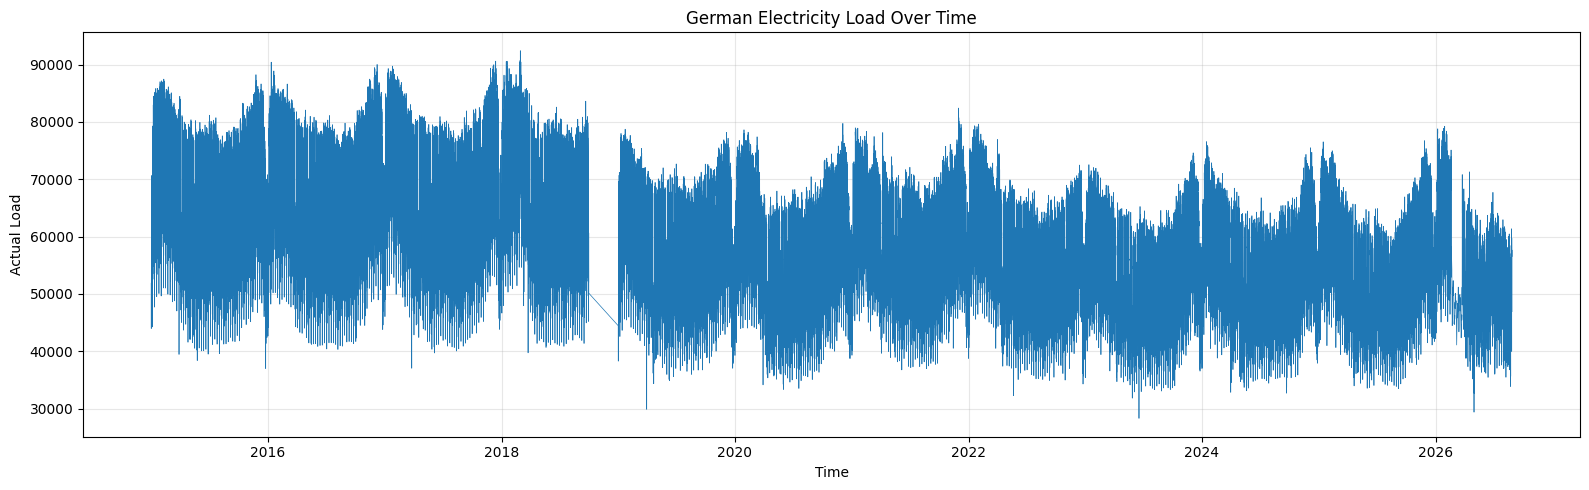

In [40]:
# EDA 2 — Electricity load over the full study period

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    df_clean.index,
    df_clean[target_column],
    linewidth=0.5
)

plt.title("German Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Actual Load")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

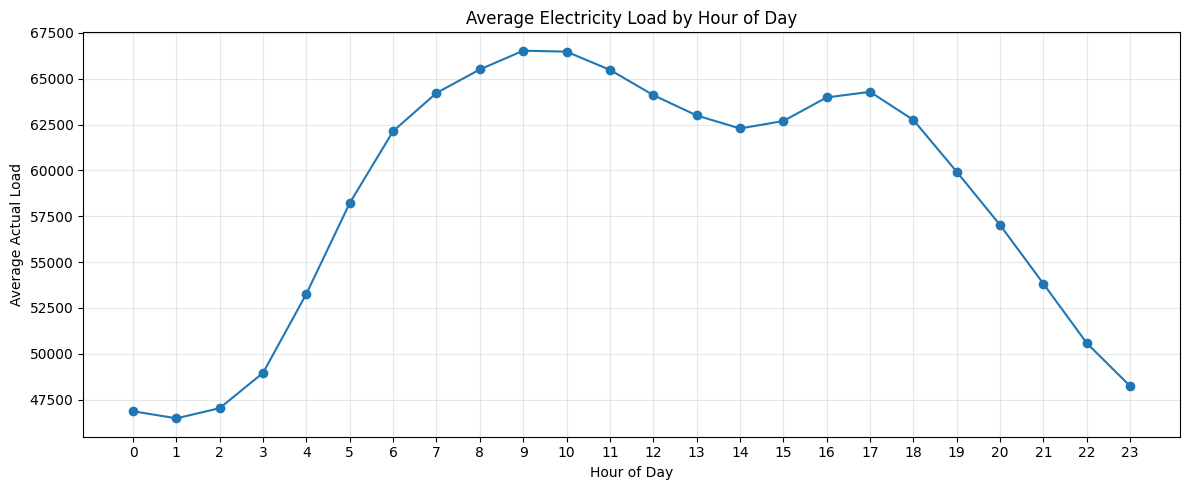

In [41]:
# EDA 3 — Average electricity load by hour of day

hourly_profile = (
    df_clean[target_column]
    .groupby(df_clean.index.hour)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title("Average Electricity Load by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Actual Load")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

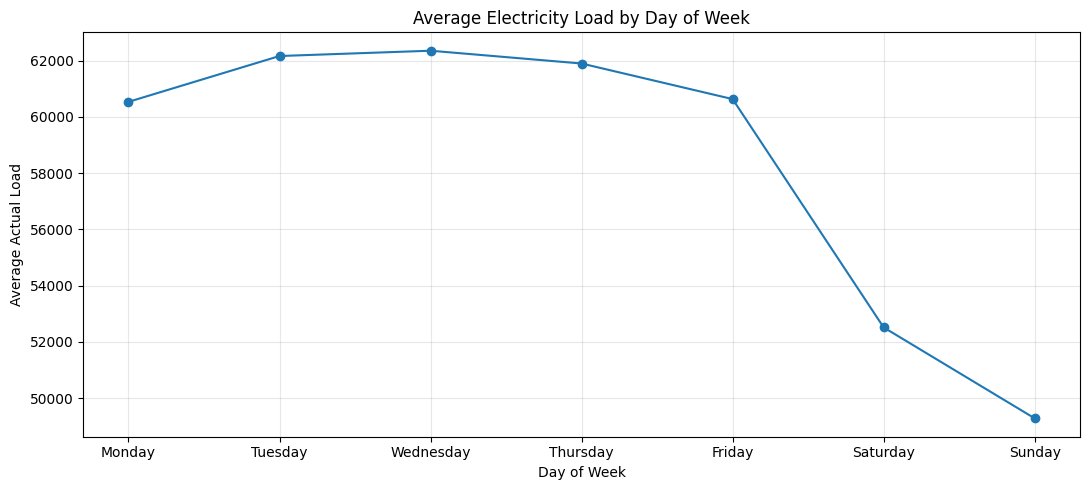

In [42]:
# EDA 4 — Average load by day of week

weekday_profile = (
    df_clean[target_column]
    .groupby(df_clean.index.dayofweek)
    .mean()
)

days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(11, 5))

plt.plot(
    days,
    weekday_profile.values,
    marker="o"
)

plt.title("Average Electricity Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Actual Load")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

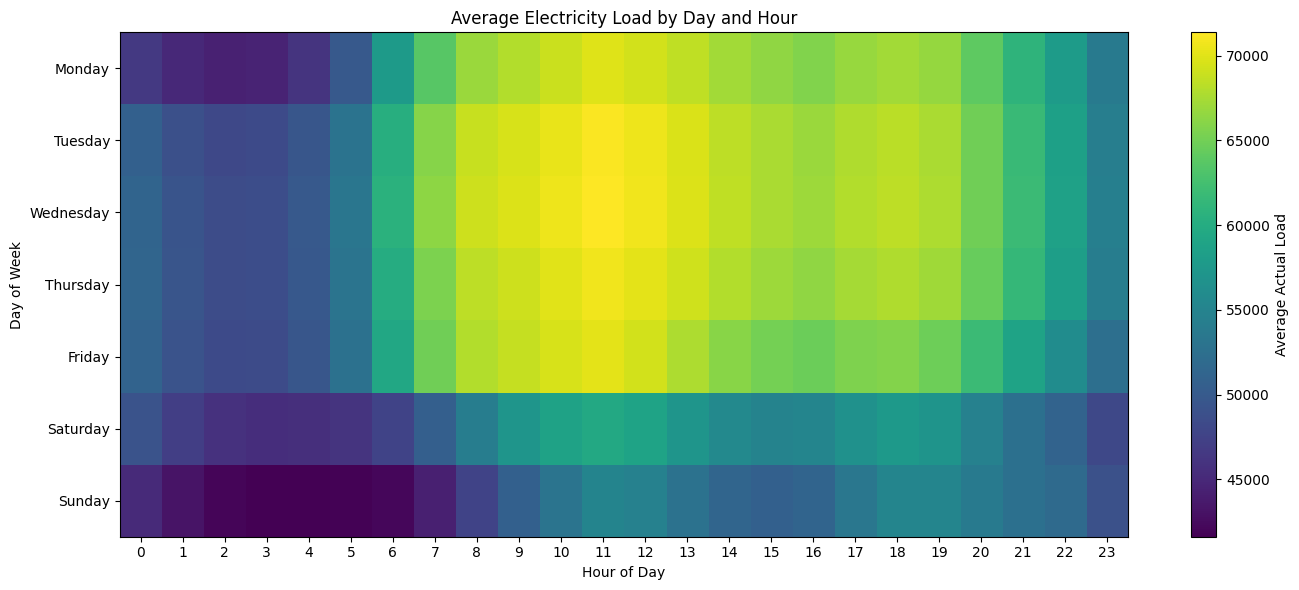

In [43]:
# EDA 5 — Average electricity load by day and hour
# Calendar features are calculated using German local time

local_time = df_clean.index.tz_convert("Europe/Berlin")

weekly_hourly = (
    df_clean[target_column]
    .groupby([local_time.dayofweek, local_time.hour])
    .mean()
    .unstack()
)

days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_hourly.index = days

plt.figure(figsize=(14, 6))

plt.imshow(
    weekly_hourly,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Average Actual Load")

plt.title("Average Electricity Load by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(range(24), range(24))
plt.yticks(range(7), days)

plt.tight_layout()
plt.show()

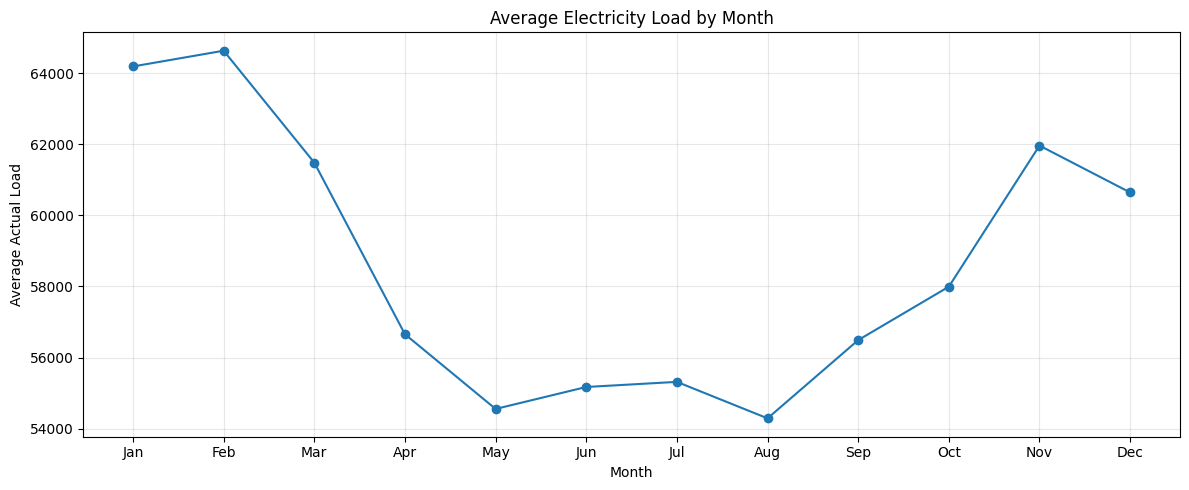

In [44]:
# EDA 6 — Average electricity load by month
# Use German local time for calendar-based analysis

local_time = df_clean.index.tz_convert("Europe/Berlin")

monthly_profile = (
    df_clean[target_column]
    .groupby(local_time.month)
    .mean()
)

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 5))

plt.plot(
    months,
    monthly_profile.values,
    marker="o"
)

plt.title("Average Electricity Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Actual Load")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

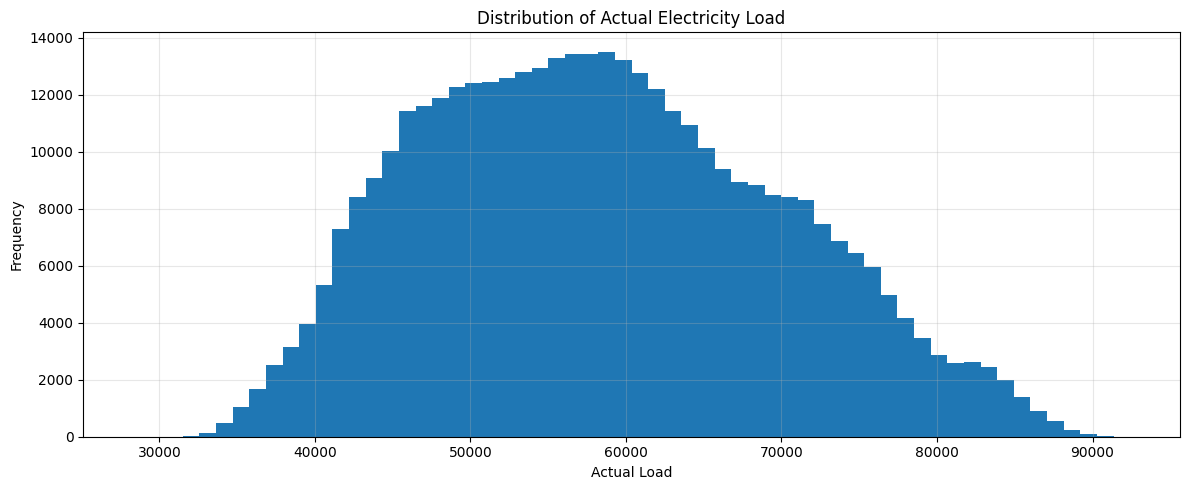

In [45]:
# EDA 7 — Distribution of actual electricity load

plt.figure(figsize=(12, 5))

plt.hist(
    df_clean[target_column],
    bins=60
)

plt.title("Distribution of Actual Electricity Load")
plt.xlabel("Actual Load")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# EDA 8 — Correlation of variables with actual load

correlation_with_target = (
    df_clean
    .corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
)

print("Variables most positively correlated with actual load:")
display(
    correlation_with_target.head(10).to_frame("correlation")
)

print("\nVariables most negatively correlated with actual load:")
display(
    correlation_with_target.tail(10).to_frame("correlation")
)

Variables most positively correlated with actual load:


,correlation
generation_Fossil Hard coal_Actual Aggregated,0.638434
generation_import_Generation_Fossil Hard coal,0.638353
generation_Biomass_Actual Aggregated,0.527668
generation_import_Generation_Biomass,0.527575
generation_import_Generation_Fossil Brown coal/Lignite,0.514293
generation_Fossil Brown coal/Lignite_Actual Aggregated,0.514285
generation_Other renewable_Actual Aggregated,0.465100
generation_import_Generation_Other renewable,0.463373
generation_Hydro Water Reservoir_Actual Aggregated,0.424780
generation_import_Generation_Hydro Water Reservoir,0.424687



Variables most negatively correlated with actual load:


,correlation
generation_import_Import_sum,-0.108226
generation_import_Import_SE_4,-0.118731
generation_Fossil Oil_Actual Aggregated,-0.119264
generation_import_Generation_Fossil Oil,-0.122396
generation_Geothermal_Actual Aggregated,-0.124902
generation_import_Generation_Geothermal,-0.124960
generation_import_Import_PL,-0.137725
generation_import_Import_NL,-0.173724
generation_import_Import_DK_1,-0.185815
generation_import_Import_FR,-0.200740


Strongest positively correlated predictor:
generation_Fossil Hard coal_Actual Aggregated
Correlation: 0.6384342773709091


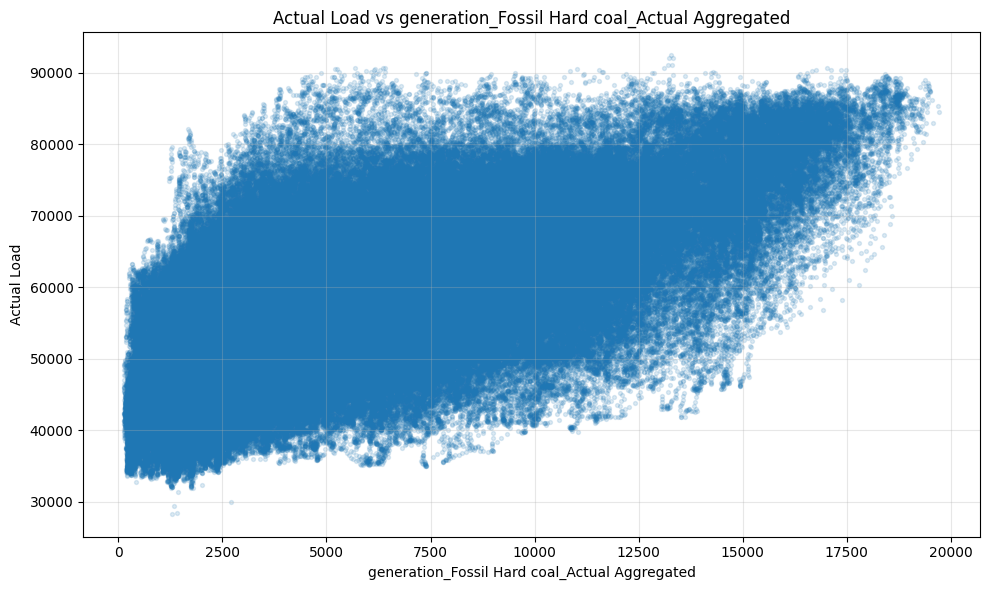

In [47]:
# EDA 9 — Strongest predictor vs actual load

strongest_predictor = correlation_with_target.index[0]

print("Strongest positively correlated predictor:")
print(strongest_predictor)
print("Correlation:", correlation_with_target.iloc[0])

plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean[strongest_predictor],
    df_clean[target_column],
    alpha=0.15,
    s=8
)

plt.title(
    f"Actual Load vs {strongest_predictor}"
)
plt.xlabel(strongest_predictor)
plt.ylabel("Actual Load")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# EDA 10 — Top predictors by absolute correlation

top_correlations = (
    correlation_with_target
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlation_table = (
    correlation_with_target
    .loc[top_correlations.index]
    .to_frame("correlation")
)

display(top_correlation_table)

,correlation
generation_Fossil Hard coal_Actual Aggregated,0.638434
generation_import_Generation_Fossil Hard coal,0.638353
generation_Biomass_Actual Aggregated,0.527668
generation_import_Generation_Biomass,0.527575
generation_import_Generation_Fossil Brown coal/Lignite,0.514293
generation_Fossil Brown coal/Lignite_Actual Aggregated,0.514285
generation_Other renewable_Actual Aggregated,0.465100
generation_import_Generation_Other renewable,0.463373
generation_Hydro Water Reservoir_Actual Aggregated,0.424780
generation_import_Generation_Hydro Water Reservoir,0.424687


In [49]:
# Feature Engineering 1 — Calendar features

local_time = df_clean.index.tz_convert("Europe/Berlin")

df_clean["hour"] = local_time.hour
df_clean["minute"] = local_time.minute
df_clean["day_of_week"] = local_time.dayofweek
df_clean["month"] = local_time.month
df_clean["day_of_year"] = local_time.dayofyear
df_clean["is_weekend"] = (local_time.dayofweek >= 5).astype(int)

print("Calendar features created successfully.")
print("\nNew features:")
print([
    "hour",
    "minute",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend"
])

print("\nUpdated shape:", df_clean.shape)

Calendar features created successfully.

New features:
['hour', 'minute', 'day_of_week', 'month', 'day_of_year', 'is_weekend']

Updated shape: (395179, 53)


In [50]:
# Feature Engineering 2 — Gap-aware lag features

# Make sure the data is in chronological order
df_clean = df_clean.sort_index()

# Create lag features using the actual timestamps
# This prevents large missing timestamp gaps from being treated as normal intervals.

for lag, feature_name in [
    (pd.Timedelta(minutes=15), "lag_15min"),
    (pd.Timedelta(hours=1), "lag_1hour"),
    (pd.Timedelta(days=1), "lag_1day"),
    (pd.Timedelta(days=7), "lag_1week")
]:
    
    previous_timestamp = df_clean.index - lag
    
    lag_series = pd.Series(
        df_clean[target_column].values,
        index=df_clean.index
    )
    
    df_clean[feature_name] = lag_series.reindex(previous_timestamp).values


print("Lag features created successfully.")

print("\nNew lag features:")
print([
    "lag_15min",
    "lag_1hour",
    "lag_1day",
    "lag_1week"
])

print("\nUpdated shape:", df_clean.shape)

print("\nMissing values in lag features:")
display(
    df_clean[
        ["lag_15min", "lag_1hour", "lag_1day", "lag_1week"]
    ].isna().sum().to_frame("missing_count")
)

Lag features created successfully.

New lag features:
['lag_15min', 'lag_1hour', 'lag_1day', 'lag_1week']

Updated shape: (395179, 57)

Missing values in lag features:


,missing_count
lag_15min,59
lag_1hour,190
lag_1day,1501
lag_1week,3023


In [51]:
# Feature Engineering 3 — Rolling load features

# Rolling statistics based only on previous load observations
# Shift by 1 so the current target is never included.

df_clean["rolling_mean_1hour"] = (
    df_clean[target_column]
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_clean["rolling_mean_1day"] = (
    df_clean[target_column]
    .shift(1)
    .rolling(window=96)
    .mean()
)

df_clean["rolling_std_1day"] = (
    df_clean[target_column]
    .shift(1)
    .rolling(window=96)
    .std()
)

print("Rolling features created successfully.")

print("\nNew rolling features:")
print([
    "rolling_mean_1hour",
    "rolling_mean_1day",
    "rolling_std_1day"
])

print("\nUpdated shape:", df_clean.shape)

print("\nMissing values in rolling features:")
display(
    df_clean[
        [
            "rolling_mean_1hour",
            "rolling_mean_1day",
            "rolling_std_1day"
        ]
    ].isna().sum().to_frame("missing_count")
)

Rolling features created successfully.

New rolling features:
['rolling_mean_1hour', 'rolling_mean_1day', 'rolling_std_1day']

Updated shape: (395179, 60)

Missing values in rolling features:


,missing_count
rolling_mean_1hour,4
rolling_mean_1day,96
rolling_std_1day,96


In [52]:
# Feature Engineering 4 — Prepare final modelling dataset

# Keep df_clean unchanged
df_model = df_clean.copy()

# Features that require historical observations
lag_features = [
    "lag_15min",
    "lag_1hour",
    "lag_1day",
    "lag_1week"
]

rolling_features = [
    "rolling_mean_1hour",
    "rolling_mean_1day",
    "rolling_std_1day"
]

history_features = lag_features + rolling_features

# Remove rows where historical features are unavailable
rows_before = len(df_model)

df_model = df_model.dropna(subset=history_features)

rows_removed = rows_before - len(df_model)

print("Final modelling dataset prepared.")
print("\nRows before:", rows_before)
print("Rows removed due to unavailable historical features:", rows_removed)
print("Rows after:", len(df_model))
print("Number of variables:", df_model.shape[1])

print("\nRemaining missing values:", df_model.isna().sum().sum())

Final modelling dataset prepared.

Rows before: 395179
Rows removed due to unavailable historical features: 4316
Rows after: 390863
Number of variables: 60

Remaining missing values: 15821


In [53]:
# Feature Engineering 5 — Remove rows with remaining missing predictors

# Keep the target separate
predictor_columns = [
    col for col in df_model.columns
    if col != target_column
]

rows_before = len(df_model)

# Remove rows where any predictor is still missing
df_model = df_model.dropna(subset=predictor_columns)

rows_removed = rows_before - len(df_model)

print("Final modelling dataset completed.")
print()
print("Rows before:", rows_before)
print("Rows removed due to missing predictors:", rows_removed)
print("Rows after:", len(df_model))
print("Variables:", df_model.shape[1])

print()
print("Remaining missing values:", df_model.isna().sum().sum())
print("Target missing values:", df_model[target_column].isna().sum())
print("Chronologically sorted:", df_model.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_model.index.duplicated().sum())

Final modelling dataset completed.

Rows before: 390863
Rows removed due to missing predictors: 10901
Rows after: 379962
Variables: 60

Remaining missing values: 0
Target missing values: 0
Chronologically sorted: True
Duplicate timestamps: 0


## 9. Chronological Train-Validation-Test Split

Since this is a time-series forecasting problem, the data is split chronologically rather than randomly.

The dataset is divided into:
- **70% Training set** — used to train the ML model
- **15% Validation set** — used for model tuning and comparison
- **15% Test set** — used for final evaluation

This ensures that future observations are never used to train the model on past observations, preventing data leakage.

In [54]:
# Model Preparation 1 — Chronological train/validation/test split

n = len(df_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_data = df_model.iloc[:train_end].copy()
validation_data = df_model.iloc[train_end:validation_end].copy()
test_data = df_model.iloc[validation_end:].copy()

print("Chronological data split completed.")
print()
print("Training set:")
print("Rows:", len(train_data))
print("Start:", train_data.index.min())
print("End:", train_data.index.max())

print("\nValidation set:")
print("Rows:", len(validation_data))
print("Start:", validation_data.index.min())
print("End:", validation_data.index.max())

print("\nTest set:")
print("Rows:", len(test_data))
print("Start:", test_data.index.min())
print("End:", test_data.index.max())

Chronological data split completed.

Training set:
Rows: 265973
Start: 2015-01-07 23:00:00+00:00
End: 2022-12-13 22:30:00+00:00

Validation set:
Rows: 56994
Start: 2022-12-13 22:45:00+00:00
End: 2024-08-04 12:00:00+00:00

Test set:
Rows: 56995
Start: 2024-08-04 12:15:00+00:00
End: 2026-06-20 22:45:00+00:00


## 10. Prepare Features and Target

The target variable is the actual electricity load. All remaining variables are used as input features for the machine learning model.

The target is separated from the predictors for the training, validation, and test sets.

In [55]:
# Model Preparation 2 — Separate features and target

X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

X_validation = validation_data.drop(columns=[target_column])
y_validation = validation_data[target_column]

X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

print("Features and target separated successfully.")
print()

print("Training:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nTest:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNumber of input features:", X_train.shape[1])

Features and target separated successfully.

Training:
X_train: (265973, 59)
y_train: (265973,)

Validation:
X_validation: (56994, 59)
y_validation: (56994,)

Test:
X_test: (56995, 59)
y_test: (56995,)

Number of input features: 59


## 11. Baseline Forecast

Before training the machine learning model, a simple persistence baseline is established.

The baseline predicts electricity load using the load observed 15 minutes earlier. This provides a reference point for evaluating whether the machine learning model provides a meaningful improvement over a simple historical-load prediction.

In [56]:
# Model 1 — 15-minute persistence baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the previous 15-minute load as the prediction
baseline_validation_pred = validation_data["lag_15min"]
baseline_test_pred = test_data["lag_15min"]

# Validation metrics
baseline_val_mae = mean_absolute_error(
    y_validation,
    baseline_validation_pred
)

baseline_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_validation_pred
    )
)

# Test metrics
baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_pred
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_pred
    )
)

print("15-Minute Persistence Baseline")
print("=" * 40)

print("\nValidation:")
print("MAE :", baseline_val_mae)
print("RMSE:", baseline_val_rmse)

print("\nTest:")
print("MAE :", baseline_test_mae)
print("RMSE:", baseline_test_rmse)

15-Minute Persistence Baseline

Validation:
MAE : 497.83914254132014
RMSE: 661.2209552318085

Test:
MAE : 519.3434431757873
RMSE: 690.2303819948773


## 12. XGBoost Time-Series Forecasting Model

An XGBoost regression model is used to forecast actual electricity load.

The model uses historical load information, lag features, rolling statistics, calendar features, and the retained electricity-system variables.

The model is trained only on historical observations and evaluated on later validation and test periods.

In [57]:
# Install XGBoost and create the forecasting model

%pip install xgboost -q

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("XGBoost installed and model created successfully.")

Note: you may need to restart the kernel to use updated packages.
XGBoost installed and model created successfully.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 12.1 Train the XGBoost Model

The XGBoost regression model is trained using the training portion of the time-series dataset.

The validation and test sets are kept separate to evaluate how well the model generalizes to future observations.

In [58]:
# Train the XGBoost forecasting model

print("Training XGBoost model...")
print("Training samples:", len(X_train))
print("Number of features:", X_train.shape[1])

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

print("\nXGBoost model trained successfully.")

Training XGBoost model...
Training samples: 265973
Number of features: 59

XGBoost model trained successfully.


## 12.2 XGBoost Model Evaluation

The trained XGBoost model is evaluated on the validation and test datasets using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

These results are compared with the 15-minute persistence baseline to determine whether the machine learning model provides a meaningful improvement.

In [59]:
# Evaluate XGBoost on validation and test sets

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Validation predictions
y_val_pred = xgb_model.predict(X_validation)

# Test predictions
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics
xgb_val_mae = mean_absolute_error(y_validation, y_val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_validation, y_val_pred))

xgb_test_mae = mean_absolute_error(y_test, y_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("XGBoost Model Performance")
print("=" * 40)

print("\nValidation:")
print("MAE :", xgb_val_mae)
print("RMSE:", xgb_val_rmse)

print("\nTest:")
print("MAE :", xgb_test_mae)
print("RMSE:", xgb_test_rmse)

print("\nComparison with 15-Minute Persistence Baseline:")
print("Validation MAE improvement:",
      baseline_val_mae - xgb_val_mae)

print("Test MAE improvement:",
      baseline_test_mae - xgb_test_mae)

XGBoost Model Performance

Validation:
MAE : 257.56119554251325
RMSE: 375.331339480503

Test:
MAE : 278.23237512520836
RMSE: 387.9870417376635

Comparison with 15-Minute Persistence Baseline:
Validation MAE improvement: 240.2779469988069
Test MAE improvement: 241.11106805057898


## 12.3 Actual vs Predicted Load

The XGBoost predictions are compared with the actual electricity load over a selected period.

This visualization helps assess how closely the machine learning model follows the real load pattern and where prediction errors occur.

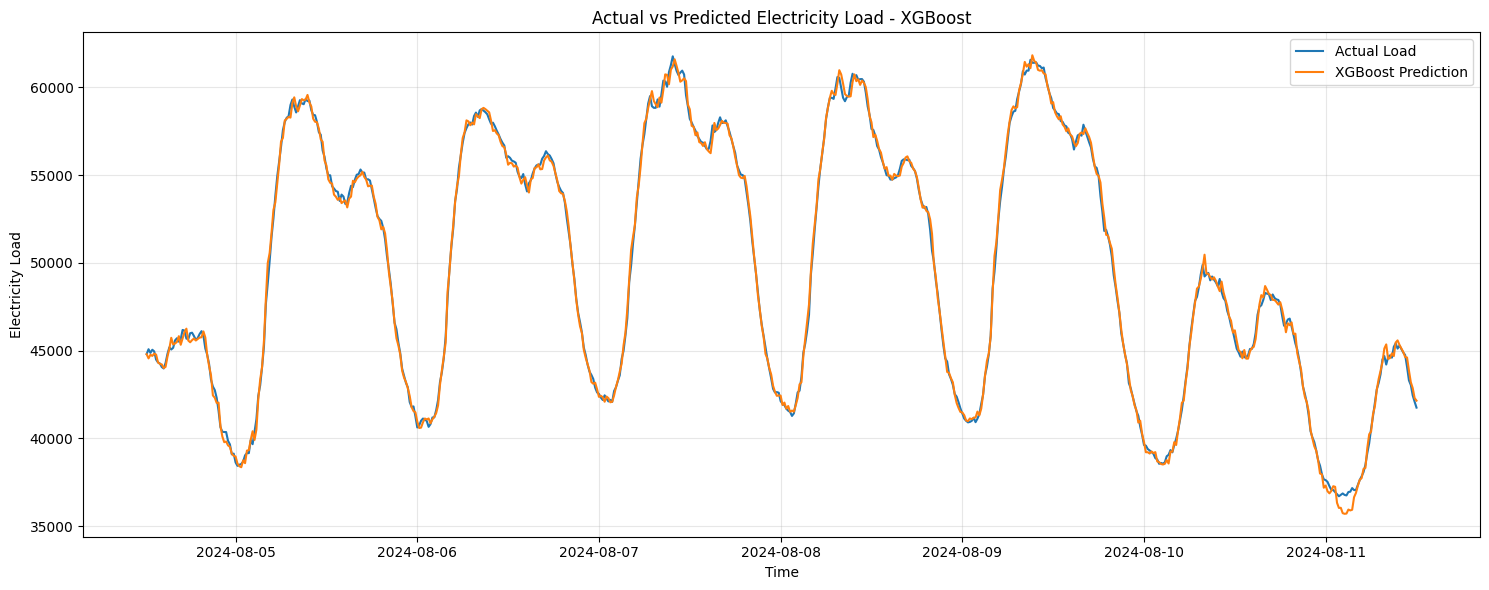

In [60]:
# Visualize actual vs predicted load on the test set

import matplotlib.pyplot as plt

# Select the first 7 days of the test set
n_points = 7 * 24 * 4

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index[:n_points],
    y_test.iloc[:n_points],
    label="Actual Load"
)

plt.plot(
    y_test.index[:n_points],
    y_test_pred[:n_points],
    label="XGBoost Prediction"
)

plt.title("Actual vs Predicted Electricity Load - XGBoost")
plt.xlabel("Time")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12.4 Prediction Error Analysis

Prediction errors are analyzed to identify periods where the XGBoost model performs well or struggles.

The residual is calculated as the difference between the actual electricity load and the predicted load.

Prediction Error Statistics
Mean Error: -38.20607213160364
Mean Absolute Error: 278.23237512520836
Minimum Error: -15722.433089999999
Maximum Error: 9814.421458750003
Standard Deviation of Error: 386.1013346371884


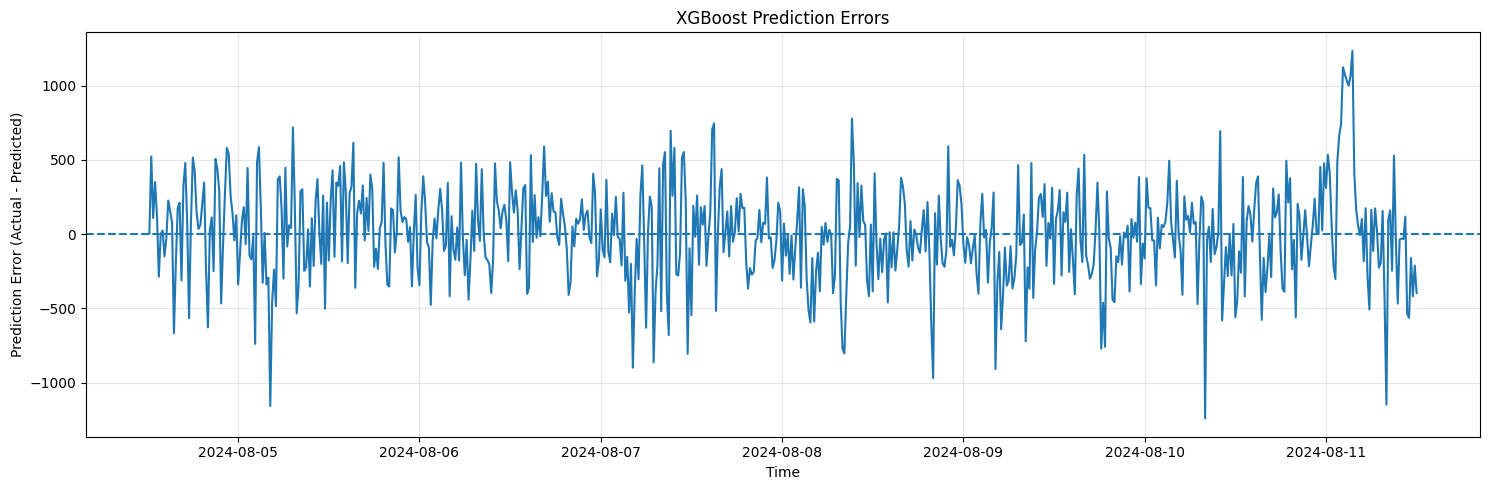

In [61]:
# Calculate prediction errors

import numpy as np
import matplotlib.pyplot as plt

errors = y_test.values - y_test_pred

print("Prediction Error Statistics")
print("===========================")
print("Mean Error:", np.mean(errors))
print("Mean Absolute Error:", np.mean(np.abs(errors)))
print("Minimum Error:", np.min(errors))
print("Maximum Error:", np.max(errors))
print("Standard Deviation of Error:", np.std(errors))

# Plot prediction errors for the first 7 days of the test set
n_points = 7 * 24 * 4

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index[:n_points],
    errors[:n_points]
)

plt.axhline(0, linestyle="--")

plt.title("XGBoost Prediction Errors")
plt.xlabel("Time")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12.5 XGBoost Feature Importance

Feature importance is examined to identify which variables contribute most to the electricity load predictions.

This helps interpret the machine learning model and identify the most useful temporal, historical, and energy-system variables.

Top 15 Most Important Features:


,importance
lag_15min,0.659197
rolling_mean_1hour,0.327009
lag_1week,0.006128
lag_1hour,0.001883
hour,0.001813
is_weekend,0.001253
lag_1day,0.000297
intraday_wind_and_solar_forecast_Solar,0.000239
rolling_mean_1day,0.000202
day_of_week,0.000180


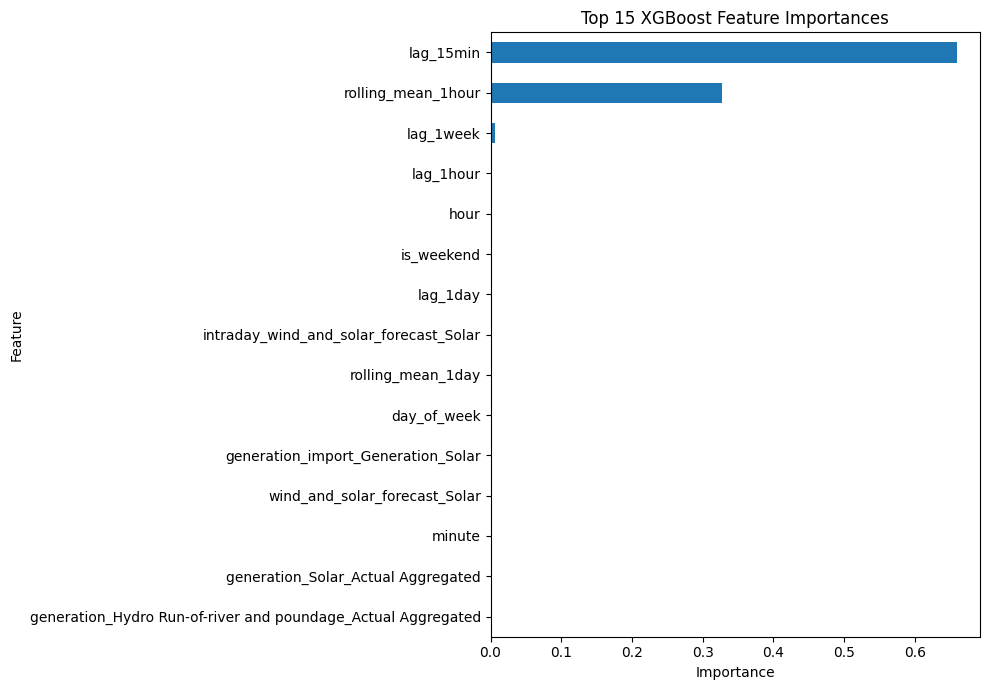

In [62]:
# XGBoost feature importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 Most Important Features:")
display(
    feature_importance.head(15).to_frame("importance")
)

# Plot top 15 features
plt.figure(figsize=(10, 7))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 12.6 Final Model Evaluation

The XGBoost forecasting model is compared with the 15-minute persistence baseline using MAE and RMSE.

Lower values indicate better forecasting performance.

In [63]:
# Final comparison of baseline and XGBoost

comparison = pd.DataFrame({
    "Model": [
        "15-Minute Persistence Baseline",
        "XGBoost"
    ],
    "Validation MAE": [
        baseline_val_mae,
        xgb_val_mae
    ],
    "Validation RMSE": [
        baseline_val_rmse,
        xgb_val_rmse
    ],
    "Test MAE": [
        baseline_test_mae,
        xgb_test_mae
    ],
    "Test RMSE": [
        baseline_test_rmse,
        xgb_test_rmse
    ]
})

display(comparison.round(2))

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE
0,15-Minute Persistence Baseline,497.84,661.22,519.34,690.23
1,XGBoost,257.56,375.33,278.23,387.99


## 13. Saving the Trained Forecasting Model

The trained XGBoost model is saved so that it can be reused by the interactive web application without retraining.

The feature names are also saved to ensure that future prediction inputs are supplied in the same structure as the training data.

In [64]:
# Save the trained XGBoost model and feature information

import joblib

# Save model
joblib.dump(xgb_model, "xgboost_load_forecasting_model.pkl")

# Save the feature names used by the model
feature_names = list(X_train.columns)
joblib.dump(feature_names, "model_features.pkl")

print("Model saved successfully.")
print("Feature information saved successfully.")
print("Number of features:", len(feature_names))

Model saved successfully.
Feature information saved successfully.
Number of features: 59


# Dataset Overview & Data Quality

## Dataset Summary

This project uses a high-frequency German electricity dataset containing electricity load, generation, imports, and renewable-energy forecast variables.

| Property | Description |
|---|---|
| Dataset | German Electricity Consumption & Generation |
| Source | Kaggle |
| Time period | 2015 – 2026 |
| Original frequency | 15 minutes |
| Original observations | 395,375 |
| Target variable | `load_Actual Load` |
| Target | Actual German electricity load |
| Original variables | 87 measurement variables + timestamp |
| Final modelling variables | 60 |
| Final modelling observations | 379,962 |
| Forecasting task | 15-minute-ahead electricity load prediction |
| Machine learning model | XGBoost Regression |

## Main Feature Groups

The dataset contains information from several parts of the German electricity system:

- **Actual electricity load**
- **Electricity generation by energy source**
- **Electricity imports and exports**
- **Wind and solar generation**
- **Wind and solar forecasts**
- **Hydroelectric generation**
- **Fossil-fuel generation**
- **Nuclear generation**
- **Biomass and other renewable generation**
- **Calendar and time-based features**
- **Historical load features (lags)**
- **Rolling statistical features**

## Data Preparation

The raw dataset was preserved separately and all preprocessing was performed on working copies.

Key preprocessing steps included:

1. Timestamp parsing and chronological ordering.
2. Identification of missing timestamps and irregular time gaps.
3. Missing-value analysis across all variables.
4. Removal of variables with substantial missingness.
5. Interpolation of only small internal gaps in retained predictor variables.
6. Removal of rows where required modelling predictors were unavailable.
7. Removal of rows with missing target values.
8. Detection and correction of an extreme load outlier.
9. Creation of calendar, lag, and rolling statistical features.
10. Chronological train/validation/test splitting to prevent future information from entering the training data.

> **Important:** Long periods with missing timestamps were not artificially filled. This avoids creating synthetic electricity-load observations where the original dataset contains no measurements.

## Final Modelling Dataset

The final dataset contains:

- **379,962 observations**
- **60 total modelling variables**
- **59 input features**
- **1 target variable**
- **0 missing values**
- **0 duplicate timestamps**
- **Chronologically ordered observations**

The forecasting model predicts electricity load using recent historical load behaviour, calendar patterns, generation information, and other available system variables.

In [65]:
# Continuous time segments using the cleaned dataset

# df_clean currently uses timestamp as its index
segment_data = df_clean[[target_column]].copy()

# Make timestamp an ordinary column for easier processing
segment_data = segment_data.reset_index()

# Make sure the timestamp column has the expected name
if "timestamp" not in segment_data.columns:
    segment_data = segment_data.rename(columns={segment_data.columns[0]: "timestamp"})

segment_data = segment_data.sort_values("timestamp").reset_index(drop=True)

# Calculate gap between consecutive observations
segment_data["time_gap"] = segment_data["timestamp"].diff()

# A new segment begins when the gap is greater than 15 minutes
segment_data["new_segment"] = (
    segment_data["time_gap"] > pd.Timedelta(minutes=15)
)

segment_data["segment_id"] = (
    segment_data["new_segment"].cumsum() + 1
)

# Create segment summary
segments = (
    segment_data
    .groupby("segment_id")
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        observations=("timestamp", "size")
    )
    .reset_index()
)

segments["duration"] = segments["end"] - segments["start"]

# Gap separating this segment from the previous segment
segments["gap_before"] = (
    segments["start"] - segments["end"].shift(1)
)

segments.loc[0, "gap_before"] = pd.Timedelta(0)

print("Continuous Time Segments — Cleaned Dataset")
print("=" * 70)

display(
    segments[
        [
            "segment_id",
            "start",
            "end",
            "duration",
            "observations",
            "gap_before"
        ]
    ]
)

print(f"\nNumber of continuous segments: {len(segments)}")

Continuous Time Segments — Cleaned Dataset


,segment_id,start,end,duration,observations,gap_before
0,1,2014-12-31 23:00:00+00:00,2015-12-30 23:30:00+00:00,364 days 00:30:00,34947,0 days 00:00:00
1,2,2015-12-31 23:00:00+00:00,2016-12-30 23:30:00+00:00,365 days 00:30:00,35043,0 days 23:30:00
2,3,2016-12-31 23:00:00+00:00,2017-12-30 23:30:00+00:00,364 days 00:30:00,34947,0 days 23:30:00
3,4,2017-12-31 23:00:00+00:00,2018-09-22 23:45:00+00:00,265 days 00:45:00,25444,0 days 23:30:00
4,5,2018-09-23 05:00:00+00:00,2018-09-30 21:45:00+00:00,7 days 16:45:00,740,0 days 05:15:00
5,6,2018-12-31 23:00:00+00:00,2019-12-30 23:30:00+00:00,364 days 00:30:00,34947,92 days 01:15:00
6,7,2019-12-31 23:00:00+00:00,2020-12-30 23:30:00+00:00,365 days 00:30:00,35043,0 days 23:30:00
7,8,2020-12-31 23:00:00+00:00,2021-12-30 23:30:00+00:00,364 days 00:30:00,34947,0 days 23:30:00
8,9,2021-12-31 23:00:00+00:00,2022-12-30 23:30:00+00:00,364 days 00:30:00,34947,0 days 23:30:00
9,10,2022-12-31 23:00:00+00:00,2023-12-30 23:30:00+00:00,364 days 00:30:00,34947,0 days 23:30:00



Number of continuous segments: 59


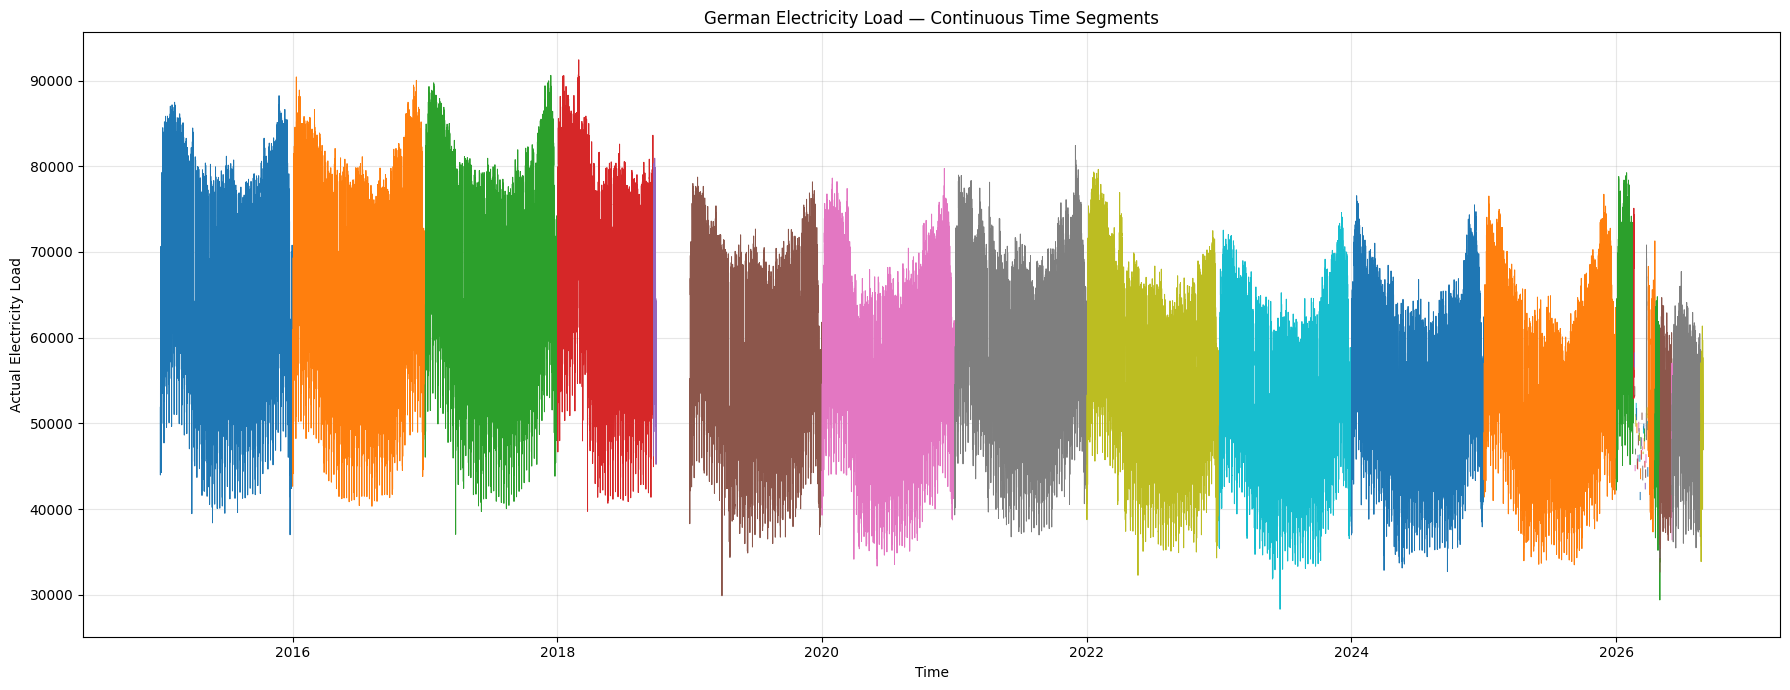

In [66]:
# Plot cleaned electricity load with a different colour for each time segment

plt.figure(figsize=(18, 7))

for _, segment in segments.iterrows():

    segment_id = segment["segment_id"]

    segment_rows = segment_data[
        segment_data["segment_id"] == segment_id
    ]

    plt.plot(
        segment_rows["timestamp"],
        segment_rows[target_column],
        linewidth=0.7,
        label=f"Segment {int(segment_id)}"
    )

plt.title("German Electricity Load — Continuous Time Segments")
plt.xlabel("Time")
plt.ylabel("Actual Electricity Load")
plt.grid(True, alpha=0.3)

# Only display legend if it remains readable
if len(segments) <= 20:
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [67]:
# Create a table of all missing timestamp periods

expected_timestamps = pd.date_range(
    start=segment_data["timestamp"].min(),
    end=segment_data["timestamp"].max(),
    freq="15min"
)

actual_timestamps = pd.DatetimeIndex(
    segment_data["timestamp"]
)

missing_timestamps = expected_timestamps.difference(
    actual_timestamps
)

# Group consecutive missing timestamps into periods
missing_df = pd.DataFrame({
    "timestamp": missing_timestamps
})

missing_df["gap_group"] = (
    missing_df["timestamp"].diff() != pd.Timedelta(minutes=15)
).cumsum()

missing_periods = (
    missing_df
    .groupby("gap_group")
    .agg(
        missing_start=("timestamp", "min"),
        missing_end=("timestamp", "max"),
        missing_records=("timestamp", "size")
    )
    .reset_index(drop=True)
)

missing_periods["missing_duration"] = (
    missing_periods["missing_end"]
    - missing_periods["missing_start"]
    + pd.Timedelta(minutes=15)
)

print("Missing Timestamp Periods")
print("=" * 80)

display(
    missing_periods[
        [
            "missing_start",
            "missing_end",
            "missing_records",
            "missing_duration"
        ]
    ]
)

print(
    f"Total missing 15-minute records: {len(missing_timestamps):,}"
)

Missing Timestamp Periods


,missing_start,missing_end,missing_records,missing_duration
0,2015-12-30 23:45:00+00:00,2015-12-31 22:45:00+00:00,93,0 days 23:15:00
1,2016-12-30 23:45:00+00:00,2016-12-31 22:45:00+00:00,93,0 days 23:15:00
2,2017-12-30 23:45:00+00:00,2017-12-31 22:45:00+00:00,93,0 days 23:15:00
3,2018-09-23 00:00:00+00:00,2018-09-23 04:45:00+00:00,20,0 days 05:00:00
4,2018-09-30 22:00:00+00:00,2018-12-31 22:45:00+00:00,8836,92 days 01:00:00
5,2019-12-30 23:45:00+00:00,2019-12-31 22:45:00+00:00,93,0 days 23:15:00
6,2020-12-30 23:45:00+00:00,2020-12-31 22:45:00+00:00,93,0 days 23:15:00
7,2021-12-30 23:45:00+00:00,2021-12-31 22:45:00+00:00,93,0 days 23:15:00
8,2022-12-30 23:45:00+00:00,2022-12-31 22:45:00+00:00,93,0 days 23:15:00
9,2023-12-30 23:45:00+00:00,2023-12-31 22:45:00+00:00,93,0 days 23:15:00


Total missing 15-minute records: 13,489


In [68]:
# Document the extreme load outlier correction

outlier_comparison = pd.DataFrame({
    "Timestamp": [
        "2026-06-25 16:30 UTC"
    ],
    "Initial Load": [
        4315702.57803
    ],
    "Corrected Load": [
        62423.10549
    ],
    "Reason": [
        "Extreme value inconsistent with surrounding electricity-load observations"
    ]
})

display(outlier_comparison)

,Timestamp,Initial Load,Corrected Load,Reason
0,2026-06-25 16:30 UTC,4.315703e+06,62423.10549,Extreme value inconsistent with surrounding el...


### Outlier Correction

One extreme value in the actual electricity-load series was identified as inconsistent with the surrounding observations.

The recorded value was approximately **4.32 million**, while neighbouring observations were approximately **62,000 MW**. The value was therefore corrected to **62,423.11 MW** based on the surrounding load pattern.

This correction prevents the anomalous observation from disproportionately affecting statistical analysis and machine-learning model training.

# Data Quality Summary

The dataset contains several important characteristics that were considered during preprocessing.

### Timestamp Quality
- The original dataset begins at **2015-01-01 00:00:00+01:00**.
- UTC conversion changes the displayed timestamp of the first observation to **2014-12-31 23:00 UTC**, but this does **not** represent additional 2014 data.
- The dataset contains irregular timestamp gaps.
- Long missing periods were identified rather than artificially interpolated.

### Missing Data
- Missing values were analysed for every measurement variable.
- Variables with substantial missingness were excluded from the modelling dataset.
- Only small internal gaps in retained predictors were interpolated.
- Missing target observations were not fabricated.

### Outlier Quality
- One extreme load observation was identified and corrected.
- The corrected value is consistent with the surrounding load observations.

### Modelling Integrity
- Data was split chronologically into training, validation, and test sets.
- Random shuffling was avoided because this is a time-series forecasting problem.
- Historical lag and rolling features were created from previous observations.
- The final modelling dataset contains no missing values or duplicate timestamps.

These preprocessing decisions ensure that the forecasting model is evaluated using historical information without artificially creating unavailable observations.

## Wind Generation Forecasting

The next forecasting target is actual wind generation.

The model will predict wind generation 15 minutes ahead using information
available at the current timestamp and historical wind-generation behavior.

A persistence baseline will first be established, followed by an XGBoost
regression model for comparison.

In [76]:
# Define wind-generation components
wind_onshore = "generation_Wind Onshore_Actual Aggregated"
wind_offshore = "generation_Wind Offshore_Actual Aggregated"

# Check availability
print("Onshore missing:", df_clean[wind_onshore].isna().sum())
print("Offshore missing:", df_clean[wind_offshore].isna().sum())

# Create total wind generation
df_clean["wind_generation_total"] = (
    df_clean[wind_onshore] + df_clean[wind_offshore]
)

print("Total wind generation missing:",
      df_clean["wind_generation_total"].isna().sum())

print("\nWind target statistics:")
print(df_clean["wind_generation_total"].describe())

Onshore missing: 184
Offshore missing: 0
Total wind generation missing: 184

Wind target statistics:
count    394995.000000
mean      13452.216991
std       10120.588909
min          43.010000
25%        5420.900000
50%       10688.480000
75%       19251.439880
max       53892.889730
Name: wind_generation_total, dtype: float64


## Wind-Specific Temporal Features

To forecast total wind generation 15 minutes ahead, we create historical
wind-generation features based only on observations available at or before
the prediction timestamp.

The features include:

- 15-minute lag
- 1-hour lag
- 1-day lag
- 1-week lag
- 1-hour rolling mean
- 1-day rolling mean
- 1-day rolling standard deviation

The target itself is not interpolated. Rows with an unavailable future
target will be removed before model training.

In [77]:
# Create a working dataframe for wind forecasting
df_wind = df_clean.copy()

wind_target = "wind_generation_total"

# Series used to construct target-specific lag features
wind_series = pd.Series(
    df_wind[wind_target].values,
    index=df_wind.index
)

# Gap-aware wind lag features
for lag, feature_name in [
    (pd.Timedelta(minutes=15), "wind_lag_15min"),
    (pd.Timedelta(hours=1), "wind_lag_1hour"),
    (pd.Timedelta(days=1), "wind_lag_1day"),
    (pd.Timedelta(days=7), "wind_lag_1week")
]:
    previous_timestamp = df_wind.index - lag

    df_wind[feature_name] = wind_series.reindex(
        previous_timestamp
    ).values

# Rolling statistics using only previous observations
df_wind["wind_rolling_mean_1hour"] = (
    df_wind[wind_target]
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_wind["wind_rolling_mean_1day"] = (
    df_wind[wind_target]
    .shift(1)
    .rolling(window=96)
    .mean()
)

df_wind["wind_rolling_std_1day"] = (
    df_wind[wind_target]
    .shift(1)
    .rolling(window=96)
    .std()
)

# Display the new features
wind_history_features = [
    "wind_lag_15min",
    "wind_lag_1hour",
    "wind_lag_1day",
    "wind_lag_1week",
    "wind_rolling_mean_1hour",
    "wind_rolling_mean_1day",
    "wind_rolling_std_1day"
]

print("Wind history features:")
print(wind_history_features)

print("\nMissing values:")
print(df_wind[wind_history_features + [wind_target]].isna().sum())

Wind history features:
['wind_lag_15min', 'wind_lag_1hour', 'wind_lag_1day', 'wind_lag_1week', 'wind_rolling_mean_1hour', 'wind_rolling_mean_1day', 'wind_rolling_std_1day']

Missing values:
wind_lag_15min              243
wind_lag_1hour              374
wind_lag_1day              1685
wind_lag_1week             3207
wind_rolling_mean_1hour     194
wind_rolling_mean_1day      470
wind_rolling_std_1day       470
wind_generation_total       184
dtype: int64


## Wind Forecasting Dataset

Rows with unavailable wind-history features or a missing wind-generation
target are removed.

The chronological split is kept consistent with the load forecasting
experiment:

- 70% training
- 15% validation
- 15% testing

No random shuffling is used so that future observations never enter the
training data.

In [78]:
# Create the wind modeling dataframe
df_wind_model = df_wind.copy()

# All predictor columns
wind_predictor_columns = [
    col for col in df_wind_model.columns
    if col != wind_target
]

# Remove rows with missing target OR missing predictor values
df_wind_model = df_wind_model.dropna(
    subset=wind_predictor_columns + [wind_target]
)

# Ensure chronological order
df_wind_model = df_wind_model.sort_index()

print("Wind modeling dataset shape:", df_wind_model.shape)
print("Missing values:", df_wind_model.isna().sum().sum())
print("Sorted:", df_wind_model.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_wind_model.index.duplicated().sum())

Wind modeling dataset shape: (379586, 68)
Missing values: 0
Sorted: True
Duplicate timestamps: 0


In [79]:
# Define features and target
wind_predictor_columns = [
    col for col in df_wind_model.columns
    if col != wind_target
]

X_wind = df_wind_model[wind_predictor_columns]
y_wind = df_wind_model[wind_target]

# Chronological 70/15/15 split
n = len(df_wind_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_wind_train = X_wind.iloc[:train_end]
y_wind_train = y_wind.iloc[:train_end]

X_wind_validation = X_wind.iloc[train_end:validation_end]
y_wind_validation = y_wind.iloc[train_end:validation_end]

X_wind_test = X_wind.iloc[validation_end:]
y_wind_test = y_wind.iloc[validation_end:]

print("Training:", X_wind_train.shape)
print("Validation:", X_wind_validation.shape)
print("Test:", X_wind_test.shape)

print("\nDate ranges:")
print("Train:", X_wind_train.index.min(), "→", X_wind_train.index.max())
print("Validation:", X_wind_validation.index.min(), "→", X_wind_validation.index.max())
print("Test:", X_wind_test.index.min(), "→", X_wind_test.index.max())

Training: (265710, 67)
Validation: (56938, 67)
Test: (56938, 67)

Date ranges:
Train: 2015-01-07 23:00:00+00:00 → 2022-12-15 02:45:00+00:00
Validation: 2022-12-15 03:00:00+00:00 → 2024-08-05 02:15:00+00:00
Test: 2024-08-05 02:30:00+00:00 → 2026-06-20 22:45:00+00:00


## Wind Persistence Baseline

The persistence model assumes that the most recently observed wind
generation will remain unchanged for the next 15 minutes.

For each timestamp `t`:

\[
\hat{y}_{t+15} = y_t
\]

This provides a simple benchmark against which the XGBoost model can be evaluated.

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Persistence prediction
wind_baseline_predictions = X_wind_test["wind_lag_15min"]

# Evaluate baseline
wind_baseline_mae = mean_absolute_error(
    y_wind_test,
    wind_baseline_predictions
)

wind_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_wind_test,
        wind_baseline_predictions
    )
)

print("Wind Persistence Baseline")
print("-" * 35)
print(f"Test MAE:  {wind_baseline_mae:.2f} MW")
print(f"Test RMSE: {wind_baseline_rmse:.2f} MW")

Wind Persistence Baseline
-----------------------------------
Test MAE:  274.89 MW
Test RMSE: 389.11 MW


## Wind Generation XGBoost Model

An XGBoost regression model is trained to forecast total wind generation
15 minutes ahead.

The model uses historical wind-generation features, calendar features,
and the available electricity-system variables.

The same XGBoost configuration used for load forecasting is used here
to maintain a consistent model comparison.

In [81]:
from xgboost import XGBRegressor

wind_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

wind_xgb_model.fit(
    X_wind_train,
    y_wind_train,
    eval_set=[(X_wind_validation, y_wind_validation)],
    verbose=False
)

print("Wind XGBoost model training completed.")

Wind XGBoost model training completed.


In [82]:
# Generate predictions
wind_xgb_predictions = wind_xgb_model.predict(X_wind_test)

# Calculate metrics
wind_xgb_mae = mean_absolute_error(
    y_wind_test,
    wind_xgb_predictions
)

wind_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_wind_test,
        wind_xgb_predictions
    )
)

print("Wind XGBoost Results")
print("-" * 35)
print(f"Test MAE:  {wind_xgb_mae:.2f} MW")
print(f"Test RMSE: {wind_xgb_rmse:.2f} MW")

Wind XGBoost Results
-----------------------------------
Test MAE:  157.27 MW
Test RMSE: 333.82 MW


In [83]:
wind_model_comparison = pd.DataFrame({
    "Model": ["Persistence", "XGBoost"],
    "Test MAE (MW)": [
        wind_baseline_mae,
        wind_xgb_mae
    ],
    "Test RMSE (MW)": [
        wind_baseline_rmse,
        wind_xgb_rmse
    ]
})

wind_mae_improvement = (
    (wind_baseline_mae - wind_xgb_mae)
    / wind_baseline_mae
    * 100
)

print(wind_model_comparison.to_string(index=False))

print(
    f"\nXGBoost MAE improvement over persistence: "
    f"{wind_mae_improvement:.2f}%"
)

      Model  Test MAE (MW)  Test RMSE (MW)
Persistence     274.893119      389.107431
    XGBoost     157.268506      333.819981

XGBoost MAE improvement over persistence: 42.79%


In [84]:
wind_feature_importance = pd.DataFrame({
    "Feature": X_wind_train.columns,
    "Importance": wind_xgb_model.feature_importances_
})

wind_feature_importance = (
    wind_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Wind Forecasting Features:")
print(wind_feature_importance.head(15).to_string(index=False))

Top 15 Wind Forecasting Features:
                                                     Feature  Importance
                                              wind_lag_15min    0.686016
                                     wind_rolling_mean_1hour    0.251867
                                              wind_lag_1hour    0.038089
                   generation_import_Generation_Wind Onshore    0.018517
                   generation_Wind Onshore_Actual Aggregated    0.002736
                  generation_Wind Offshore_Actual Aggregated    0.000394
                                                  is_weekend    0.000285
                        wind_and_solar_forecast_Wind Onshore    0.000278
                  generation_import_Generation_Wind Offshore    0.000185
                                                        hour    0.000082
generation_Hydro Run-of-river and poundage_Actual Aggregated    0.000068
                     generation_import_Generation_Fossil Oil    0.000057
               in

## Wind Generation: Actual vs Predicted

The following plot compares actual wind generation with the XGBoost
forecast over a representative period from the test set.

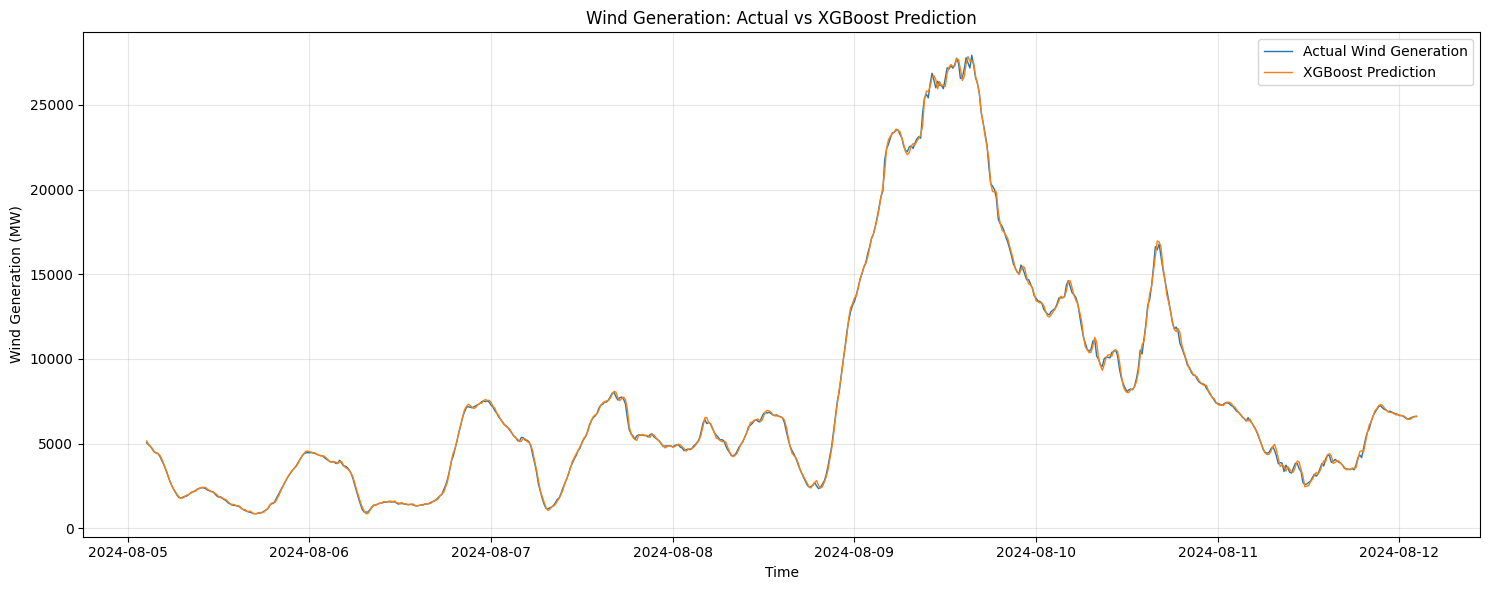

In [85]:
import matplotlib.pyplot as plt

# Plot the first 7 days of the wind test set
plot_points = 7 * 96  # 7 days × 96 observations per day

plt.figure(figsize=(15, 6))

plt.plot(
    y_wind_test.index[:plot_points],
    y_wind_test.iloc[:plot_points],
    label="Actual Wind Generation",
    linewidth=1
)

plt.plot(
    y_wind_test.index[:plot_points],
    wind_xgb_predictions[:plot_points],
    label="XGBoost Prediction",
    linewidth=1
)

plt.title("Wind Generation: Actual vs XGBoost Prediction")
plt.xlabel("Time")
plt.ylabel("Wind Generation (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Solar Generation Forecasting

The next forecasting target is actual solar generation.

Solar generation is represented by the aggregated actual solar generation
column. The model will forecast solar generation 15 minutes ahead using
historical solar-generation behavior and the available electricity-system
features.

In [86]:
# Define solar target
solar_target = "generation_Solar_Actual Aggregated"

# Check target availability
print("Solar target missing:", df_clean[solar_target].isna().sum())

print("\nSolar target statistics:")
print(df_clean[solar_target].describe())

Solar target missing: 184

Solar target statistics:
count    394995.000000
mean       5942.842067
std        9469.589689
min           0.000000
25%           0.600000
50%         137.010000
75%        9217.045000
max       58810.055000
Name: generation_Solar_Actual Aggregated, dtype: float64


## Solar-Specific Temporal Features

Solar generation has strong short-term and daily patterns. To capture this
behavior, solar-specific lag and rolling features are created using only
information available before the prediction timestamp.

The features include:

- 15-minute lag
- 1-hour lag
- 1-day lag
- 1-week lag
- 1-hour rolling mean
- 1-day rolling mean
- 1-day rolling standard deviation

In [87]:
# Create a working dataframe for solar forecasting
df_solar = df_clean.copy()

# Series used to construct solar-specific lag features
solar_series = pd.Series(
    df_solar[solar_target].values,
    index=df_solar.index
)

# Gap-aware solar lag features
for lag, feature_name in [
    (pd.Timedelta(minutes=15), "solar_lag_15min"),
    (pd.Timedelta(hours=1), "solar_lag_1hour"),
    (pd.Timedelta(days=1), "solar_lag_1day"),
    (pd.Timedelta(days=7), "solar_lag_1week")
]:
    previous_timestamp = df_solar.index - lag

    df_solar[feature_name] = solar_series.reindex(
        previous_timestamp
    ).values

# Rolling statistics using only previous observations
df_solar["solar_rolling_mean_1hour"] = (
    df_solar[solar_target]
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_solar["solar_rolling_mean_1day"] = (
    df_solar[solar_target]
    .shift(1)
    .rolling(window=96)
    .mean()
)

df_solar["solar_rolling_std_1day"] = (
    df_solar[solar_target]
    .shift(1)
    .rolling(window=96)
    .std()
)

# Check the new features
solar_history_features = [
    "solar_lag_15min",
    "solar_lag_1hour",
    "solar_lag_1day",
    "solar_lag_1week",
    "solar_rolling_mean_1hour",
    "solar_rolling_mean_1day",
    "solar_rolling_std_1day"
]

print("Solar history features:")
print(solar_history_features)

print("\nMissing values:")
print(
    df_solar[
        solar_history_features + [solar_target]
    ].isna().sum()
)

Solar history features:
['solar_lag_15min', 'solar_lag_1hour', 'solar_lag_1day', 'solar_lag_1week', 'solar_rolling_mean_1hour', 'solar_rolling_mean_1day', 'solar_rolling_std_1day']

Missing values:
solar_lag_15min                        243
solar_lag_1hour                        374
solar_lag_1day                        1685
solar_lag_1week                       3207
solar_rolling_mean_1hour               194
solar_rolling_mean_1day                470
solar_rolling_std_1day                 470
generation_Solar_Actual Aggregated     184
dtype: int64


## Solar Forecasting Dataset

Rows with missing solar-generation history or a missing solar target are
removed before modeling.

The data is then divided chronologically into 70% training, 15% validation,
and 15% testing sets. No random shuffling is used.

In [88]:
# Create the solar modeling dataframe
df_solar_model = df_solar.copy()

# All predictor columns
solar_predictor_columns = [
    col for col in df_solar_model.columns
    if col != solar_target
]

# Remove rows with missing target or predictor values
df_solar_model = df_solar_model.dropna(
    subset=solar_predictor_columns + [solar_target]
)

# Ensure chronological order
df_solar_model = df_solar_model.sort_index()

print("Solar modeling dataset shape:", df_solar_model.shape)
print("Missing values:", df_solar_model.isna().sum().sum())
print("Sorted:", df_solar_model.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_solar_model.index.duplicated().sum())

Solar modeling dataset shape: (379586, 68)
Missing values: 0
Sorted: True
Duplicate timestamps: 0


In [89]:
# Define features and target
solar_predictor_columns = [
    col for col in df_solar_model.columns
    if col != solar_target
]

X_solar = df_solar_model[solar_predictor_columns]
y_solar = df_solar_model[solar_target]

# Chronological 70/15/15 split
n = len(df_solar_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_solar_train = X_solar.iloc[:train_end]
y_solar_train = y_solar.iloc[:train_end]

X_solar_validation = X_solar.iloc[train_end:validation_end]
y_solar_validation = y_solar.iloc[train_end:validation_end]

X_solar_test = X_solar.iloc[validation_end:]
y_solar_test = y_solar.iloc[validation_end:]

print("Training:", X_solar_train.shape)
print("Validation:", X_solar_validation.shape)
print("Test:", X_solar_test.shape)

print("\nDate ranges:")
print(
    "Train:",
    X_solar_train.index.min(),
    "→",
    X_solar_train.index.max()
)
print(
    "Validation:",
    X_solar_validation.index.min(),
    "→",
    X_solar_validation.index.max()
)
print(
    "Test:",
    X_solar_test.index.min(),
    "→",
    X_solar_test.index.max()
)

Training: (265710, 67)
Validation: (56938, 67)
Test: (56938, 67)

Date ranges:
Train: 2015-01-07 23:00:00+00:00 → 2022-12-15 02:45:00+00:00
Validation: 2022-12-15 03:00:00+00:00 → 2024-08-05 02:15:00+00:00
Test: 2024-08-05 02:30:00+00:00 → 2026-06-20 22:45:00+00:00


## Solar Persistence Baseline

The persistence model assumes that the most recently observed solar
generation will remain unchanged for the next 15 minutes.

For each timestamp `t`:

\[
\hat{y}_{t+15} = y_t
\]

This provides a simple benchmark for evaluating the solar XGBoost model.

In [90]:
# Solar persistence prediction
solar_baseline_predictions = X_solar_test["solar_lag_15min"]

# Evaluate baseline
solar_baseline_mae = mean_absolute_error(
    y_solar_test,
    solar_baseline_predictions
)

solar_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_solar_test,
        solar_baseline_predictions
    )
)

print("Solar Persistence Baseline")
print("-" * 35)
print(f"Test MAE:  {solar_baseline_mae:.2f} MW")
print(f"Test RMSE: {solar_baseline_rmse:.2f} MW")

Solar Persistence Baseline
-----------------------------------
Test MAE:  528.67 MW
Test RMSE: 920.27 MW


## Solar Generation XGBoost Model

An XGBoost regression model is trained to forecast total solar generation
15 minutes ahead.

The model uses the solar-specific historical features together with the
available calendar and electricity-system features. 

In [91]:
from xgboost import XGBRegressor

solar_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

solar_xgb_model.fit(
    X_solar_train,
    y_solar_train,
    eval_set=[(X_solar_validation, y_solar_validation)],
    verbose=False
)

print("Solar XGBoost model training completed.")

Solar XGBoost model training completed.


In [92]:
# Generate predictions
solar_xgb_predictions = solar_xgb_model.predict(X_solar_test)

# Calculate metrics
solar_xgb_mae = mean_absolute_error(
    y_solar_test,
    solar_xgb_predictions
)

solar_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_solar_test,
        solar_xgb_predictions
    )
)

print("Solar XGBoost Results")
print("-" * 35)
print(f"Test MAE:  {solar_xgb_mae:.2f} MW")
print(f"Test RMSE: {solar_xgb_rmse:.2f} MW")

Solar XGBoost Results
-----------------------------------
Test MAE:  451.24 MW
Test RMSE: 1922.21 MW


In [93]:
# Solar prediction error analysis

solar_errors = y_solar_test.values - solar_xgb_predictions

solar_error_analysis = pd.DataFrame({
    "timestamp": y_solar_test.index,
    "actual": y_solar_test.values,
    "predicted": solar_xgb_predictions,
    "error": solar_errors,
    "absolute_error": np.abs(solar_errors)
})

print("Prediction statistics:")
print(f"Minimum prediction: {solar_xgb_predictions.min():.2f} MW")
print(f"Maximum prediction: {solar_xgb_predictions.max():.2f} MW")
print(f"Mean prediction:    {solar_xgb_predictions.mean():.2f} MW")
print(f"Median prediction:  {np.median(solar_xgb_predictions):.2f} MW")

print("\nError statistics:")
print(f"Mean error:          {solar_errors.mean():.2f} MW")
print(f"Maximum absolute error: {np.abs(solar_errors).max():.2f} MW")

print("\n10 largest errors:")
print(
    solar_error_analysis
    .sort_values("absolute_error", ascending=False)
    .head(10)
    .to_string(index=False)
)

Prediction statistics:
Minimum prediction: -13.48 MW
Maximum prediction: 36917.21 MW
Mean prediction:    7351.76 MW
Median prediction:  76.44 MW

Error statistics:
Mean error:          400.92 MW
Maximum absolute error: 20855.61 MW

10 largest errors:
                timestamp    actual    predicted        error  absolute_error
2026-05-28 12:15:00+00:00 55770.126 34914.519531 20855.606469    20855.606469
2026-05-28 11:00:00+00:00 56739.178 36022.921875 20716.256125    20716.256125
2026-05-28 12:00:00+00:00 55441.818 35073.757812 20368.060187    20368.060187
2026-05-28 12:30:00+00:00 55079.437 34716.578125 20362.858875    20362.858875
2026-05-28 10:15:00+00:00 56536.860 36258.562500 20278.297500    20278.297500
2026-05-28 10:45:00+00:00 56330.384 36075.375000 20255.009000    20255.009000
2026-05-28 10:30:00+00:00 56363.372 36156.835938 20206.536063    20206.536063
2026-05-28 10:00:00+00:00 56217.022 36227.101562 19989.920437    19989.920437
2026-05-28 11:15:00+00:00 56019.610 36030.73046

In [94]:
# Inspect the solar target and historical features around the
# period with the largest XGBoost errors.

problem_date = pd.Timestamp("2026-05-28", tz="UTC")

inspection_columns = [
    solar_target,
    "solar_lag_15min",
    "solar_lag_1hour",
    "solar_lag_1day",
    "solar_lag_1week",
    "solar_rolling_mean_1hour",
    "solar_rolling_mean_1day",
    "solar_rolling_std_1day"
]

solar_problem_period = df_solar_model.loc[
    problem_date - pd.Timedelta(hours=6):
    problem_date + pd.Timedelta(hours=6),
    inspection_columns
]

print(solar_problem_period.to_string())

                           generation_Solar_Actual Aggregated  solar_lag_15min  solar_lag_1hour  solar_lag_1day  solar_lag_1week  solar_rolling_mean_1hour  solar_rolling_mean_1day  solar_rolling_std_1day
timestamp                                                                                                                                                                                                  
2026-05-27 18:00:00+00:00                            3496.135         4965.673        11168.277        3292.365         1975.561                7895.27350             19404.151135            20566.727721
2026-05-27 18:15:00+00:00                            2283.818         3496.135         8748.563        2168.397         1240.880                5977.23800             19406.273740            20565.057836
2026-05-27 18:30:00+00:00                            1329.458         2283.818         6698.581        1244.604          611.815                4361.05175             19407.476042     

In [95]:
# Compare persistence and XGBoost errors on May 28, 2026

problem_mask = (
    y_solar_test.index.date ==
    problem_date.date()
)

actual_problem = y_solar_test[problem_mask]
xgb_problem = solar_xgb_predictions[problem_mask]
persistence_problem = solar_baseline_predictions[problem_mask]

print("May 28, 2026 performance")
print("-" * 40)

print(
    f"Persistence MAE: "
    f"{mean_absolute_error(actual_problem, persistence_problem):.2f} MW"
)

print(
    f"XGBoost MAE:      "
    f"{mean_absolute_error(actual_problem, xgb_problem):.2f} MW"
)

print(
    f"Actual maximum:   "
    f"{actual_problem.max():.2f} MW"
)

print(
    f"XGBoost maximum:  "
    f"{xgb_problem.max():.2f} MW"
)

May 28, 2026 performance
----------------------------------------
Persistence MAE: 1196.11 MW
XGBoost MAE:      5086.60 MW
Actual maximum:   56739.18 MW
XGBoost maximum:  36258.56 MW


In [96]:
# Compare solar-generation ranges across train, validation and test

print("Solar generation ranges")
print("-" * 50)

print(
    f"Training   : min={y_solar_train.min():.2f} MW, "
    f"max={y_solar_train.max():.2f} MW"
)

print(
    f"Validation : min={y_solar_validation.min():.2f} MW, "
    f"max={y_solar_validation.max():.2f} MW"
)

print(
    f"Test       : min={y_solar_test.min():.2f} MW, "
    f"max={y_solar_test.max():.2f} MW"
)

Solar generation ranges
--------------------------------------------------
Training   : min=0.03 MW, max=38108.09 MW
Validation : min=1.30 MW, max=47332.06 MW
Test       : min=0.00 MW, max=56739.18 MW


In [97]:
# Check how often test solar generation exceeds the training maximum

training_max = y_solar_train.max()

above_training_max = (y_solar_test > training_max).sum()
percentage_above = above_training_max / len(y_solar_test) * 100

print(f"Training maximum: {training_max:.2f} MW")
print(
    f"Test observations above training maximum: "
    f"{above_training_max}"
)
print(
    f"Percentage of test observations above training maximum: "
    f"{percentage_above:.2f}%"
)

Training maximum: 38108.09 MW
Test observations above training maximum: 2322
Percentage of test observations above training maximum: 4.08%


In [98]:
# Compare model performance inside and outside the training target range

within_range = y_solar_test <= training_max
above_range = y_solar_test > training_max

# Predictions for each group
actual_within = y_solar_test[within_range]
pred_within = solar_xgb_predictions[within_range]
baseline_within = solar_baseline_predictions[within_range]

actual_above = y_solar_test[above_range]
pred_above = solar_xgb_predictions[above_range]
baseline_above = solar_baseline_predictions[above_range]

print("Solar XGBoost performance by target range")
print("=" * 55)

print(f"\nObservations within training range: {within_range.sum()}")
print(f"Observations above training range:  {above_range.sum()}")

print("\n--- Within training range ---")
print(
    f"XGBoost MAE:     "
    f"{mean_absolute_error(actual_within, pred_within):.2f} MW"
)
print(
    f"Persistence MAE: "
    f"{mean_absolute_error(actual_within, baseline_within):.2f} MW"
)

print("\n--- Above training maximum ---")
print(
    f"XGBoost MAE:     "
    f"{mean_absolute_error(actual_above, pred_above):.2f} MW"
)
print(
    f"Persistence MAE: "
    f"{mean_absolute_error(actual_above, baseline_above):.2f} MW"
)

Solar XGBoost performance by target range

Observations within training range: 54616
Observations above training range:  2322

--- Within training range ---
XGBoost MAE:     106.46 MW
Persistence MAE: 518.61 MW

--- Above training maximum ---
XGBoost MAE:     8560.86 MW
Persistence MAE: 765.37 MW


## Solar Delta Forecasting

The direct XGBoost model performs well within the historical training range
but struggles when test-period solar generation exceeds the maximum value
observed during training.

To address this, a delta-based formulation is tested.

Instead of predicting the absolute solar-generation level, the model predicts
the change in solar generation over the next 15 minutes:

    Delta Solar = Solar(t+15) - Solar(t)

The predicted change is then added to the most recent observed solar
generation to obtain the final forecast.

In [99]:
# Create a copy of the solar modeling dataset
df_solar_delta = df_solar_model.copy()

# Predict the 15-minute change in solar generation
df_solar_delta["solar_delta"] = (
    df_solar_delta[solar_target]
    - df_solar_delta["solar_lag_15min"]
)

print("Solar delta statistics:")
print(df_solar_delta["solar_delta"].describe())

Solar delta statistics:
count    379586.000000
mean          0.335331
std         671.981125
min       -4747.300000
25%         -79.545000
50%           0.000000
75%          45.880000
max        6628.760000
Name: solar_delta, dtype: float64


In [100]:
# Features remain the same
solar_delta_predictor_columns = [
    col for col in df_solar_delta.columns
    if col not in [solar_target, "solar_delta"]
]

X_solar_delta = df_solar_delta[solar_delta_predictor_columns]
y_solar_delta = df_solar_delta["solar_delta"]

n = len(df_solar_delta)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_solar_delta_train = X_solar_delta.iloc[:train_end]
y_solar_delta_train = y_solar_delta.iloc[:train_end]

X_solar_delta_validation = X_solar_delta.iloc[train_end:validation_end]
y_solar_delta_validation = y_solar_delta.iloc[train_end:validation_end]

X_solar_delta_test = X_solar_delta.iloc[validation_end:]
y_solar_delta_test = y_solar_delta.iloc[validation_end:]

print("Training:", X_solar_delta_train.shape)
print("Validation:", X_solar_delta_validation.shape)
print("Test:", X_solar_delta_test.shape)

Training: (265710, 67)
Validation: (56938, 67)
Test: (56938, 67)


## Solar Delta XGBoost Model

The delta model predicts the change in solar generation over the next
15 minutes rather than predicting the absolute generation level.

The predicted change is then added to the most recently observed solar
generation to obtain the final forecast.

In [101]:
# Train XGBoost on the solar-generation change

solar_delta_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

solar_delta_xgb_model.fit(
    X_solar_delta_train,
    y_solar_delta_train,
    eval_set=[(X_solar_delta_validation, y_solar_delta_validation)],
    verbose=False
)

print("Solar delta XGBoost model training completed.")

Solar delta XGBoost model training completed.


In [102]:
# Predict the change in solar generation
solar_delta_predictions = solar_delta_xgb_model.predict(
    X_solar_delta_test
)

# Reconstruct the absolute solar-generation forecast
solar_delta_xgb_predictions = (
    X_solar_delta_test["solar_lag_15min"].values
    + solar_delta_predictions
)

# Evaluate
solar_delta_xgb_mae = mean_absolute_error(
    y_solar_test,
    solar_delta_xgb_predictions
)

solar_delta_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_solar_test,
        solar_delta_xgb_predictions
    )
)

print("Solar Delta XGBoost Results")
print("-" * 40)
print(f"Test MAE:  {solar_delta_xgb_mae:.2f} MW")
print(f"Test RMSE: {solar_delta_xgb_rmse:.2f} MW")

Solar Delta XGBoost Results
----------------------------------------
Test MAE:  105.32 MW
Test RMSE: 235.93 MW


In [103]:
# Evaluate the delta model on observations above the
# training-period maximum solar generation

above_range = y_solar_test > training_max

actual_above = y_solar_test[above_range]
delta_pred_above = solar_delta_xgb_predictions[above_range]

print("Solar Delta XGBoost — Above Training Maximum")
print("=" * 55)

print(f"Observations: {above_range.sum()}")

print(
    f"Delta XGBoost MAE: "
    f"{mean_absolute_error(actual_above, delta_pred_above):.2f} MW"
)

print(
    f"Delta XGBoost RMSE: "
    f"{np.sqrt(mean_squared_error(actual_above, delta_pred_above)):.2f} MW"
)

print(
    f"Maximum actual: "
    f"{actual_above.max():.2f} MW"
)

print(
    f"Maximum prediction: "
    f"{delta_pred_above.max():.2f} MW"
)

Solar Delta XGBoost — Above Training Maximum
Observations: 2322
Delta XGBoost MAE: 353.38 MW
Delta XGBoost RMSE: 489.67 MW
Maximum actual: 56739.18 MW
Maximum prediction: 56702.77 MW


## Solar Model Comparison

Three forecasting approaches were evaluated for 15-minute-ahead solar
generation:

1. Persistence baseline
2. Direct XGBoost regression
3. Delta XGBoost regression

The delta formulation predicts the change in solar generation and then
reconstructs the absolute forecast from the latest observed value.

In [104]:
solar_model_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Direct XGBoost",
        "Delta XGBoost"
    ],
    "Test MAE (MW)": [
        solar_baseline_mae,
        solar_xgb_mae,
        solar_delta_xgb_mae
    ],
    "Test RMSE (MW)": [
        solar_baseline_rmse,
        solar_xgb_rmse,
        solar_delta_xgb_rmse
    ]
})

print(solar_model_comparison.to_string(index=False))

solar_delta_improvement = (
    (solar_baseline_mae - solar_delta_xgb_mae)
    / solar_baseline_mae
    * 100
)

print(
    f"\nDelta XGBoost MAE improvement over persistence: "
    f"{solar_delta_improvement:.2f}%"
)

         Model  Test MAE (MW)  Test RMSE (MW)
   Persistence     528.669060      920.274389
Direct XGBoost     451.241938     1922.205804
 Delta XGBoost     105.323711      235.933846

Delta XGBoost MAE improvement over persistence: 80.08%


In [105]:
solar_delta_feature_importance = pd.DataFrame({
    "Feature": X_solar_delta_train.columns,
    "Importance": solar_delta_xgb_model.feature_importances_
})

solar_delta_feature_importance = (
    solar_delta_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Solar Delta Forecasting Features:")
print(
    solar_delta_feature_importance
    .head(15)
    .to_string(index=False)
)

Top 15 Solar Delta Forecasting Features:
                                                     Feature  Importance
                                                        hour    0.427594
                                             solar_lag_1hour    0.129396
                               wind_and_solar_forecast_Solar    0.096028
                          generation_import_Generation_Solar    0.079181
                                      solar_rolling_std_1day    0.039504
                      intraday_wind_and_solar_forecast_Solar    0.033769
                                    solar_rolling_mean_1hour    0.029895
                                             solar_lag_15min    0.025340
                                     solar_rolling_mean_1day    0.020864
                                                      minute    0.014694
                                                       month    0.013977
                                                 day_of_year    0.012458
generation

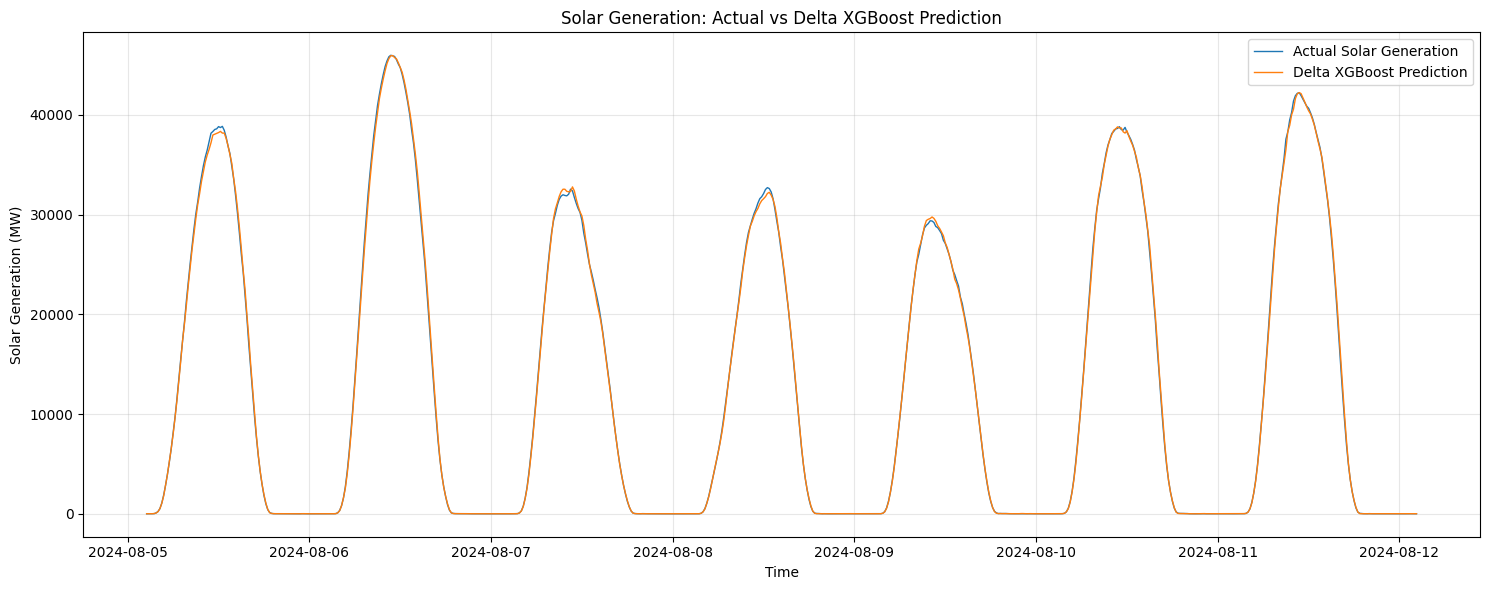

In [106]:
# Plot the first 7 days of the solar test set
plot_points = 7 * 96

plt.figure(figsize=(15, 6))

plt.plot(
    y_solar_test.index[:plot_points],
    y_solar_test.iloc[:plot_points],
    label="Actual Solar Generation",
    linewidth=1
)

plt.plot(
    y_solar_test.index[:plot_points],
    solar_delta_xgb_predictions[:plot_points],
    label="Delta XGBoost Prediction",
    linewidth=1
)

plt.title("Solar Generation: Actual vs Delta XGBoost Prediction")
plt.xlabel("Time")
plt.ylabel("Solar Generation (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Hydro Generation Forecasting

The next forecasting target is total actual hydro generation.

Total hydro generation is calculated from the three available aggregated
hydro-generation components:

- Hydro Run-of-river and poundage
- Hydro Water Reservoir
- Hydro Pumped Storage

The combined target will be forecast 15 minutes ahead using historical
hydro-generation behavior and the available electricity-system features.

In [107]:
# Define hydro-generation components
hydro_run_of_river = (
    "generation_Hydro Run-of-river and poundage_Actual Aggregated"
)

hydro_water_reservoir = (
    "generation_Hydro Water Reservoir_Actual Aggregated"
)

hydro_pumped_storage = (
    "generation_Hydro Pumped Storage_Actual Aggregated"
)

hydro_components = [
    hydro_run_of_river,
    hydro_water_reservoir,
    hydro_pumped_storage
]

# Check missing values in each component
print("Hydro component missing values:")
print(df_clean[hydro_components].isna().sum())

# Create total hydro generation
df_clean["hydro_generation_total"] = (
    df_clean[hydro_run_of_river]
    + df_clean[hydro_water_reservoir]
    + df_clean[hydro_pumped_storage]
)

print("\nTotal hydro generation missing:")
print(df_clean["hydro_generation_total"].isna().sum())

print("\nTotal hydro generation statistics:")
print(df_clean["hydro_generation_total"].describe())

Hydro component missing values:
generation_Hydro Run-of-river and poundage_Actual Aggregated      0
generation_Hydro Water Reservoir_Actual Aggregated              308
generation_Hydro Pumped Storage_Actual Aggregated               372
dtype: int64

Total hydro generation missing:
680

Total hydro generation statistics:
count    394499.000000
mean       4130.626660
std        2647.567299
min         750.816530
25%        2013.720000
50%        3308.610000
75%        5689.960000
max       17492.780000
Name: hydro_generation_total, dtype: float64


## Hydro-Specific Temporal Features

To forecast total hydro generation 15 minutes ahead, hydro-specific
historical features are created from the combined hydro-generation target.

The features include:

- 15-minute lag
- 1-hour lag
- 1-day lag
- 1-week lag
- 1-hour rolling mean
- 1-day rolling mean
- 1-day rolling standard deviation

All historical features use only observations available before the
prediction timestamp.

In [108]:
# Create a working dataframe for hydro forecasting
df_hydro = df_clean.copy()

hydro_target = "hydro_generation_total"

# Series used to construct hydro-specific lag features
hydro_series = pd.Series(
    df_hydro[hydro_target].values,
    index=df_hydro.index
)

# Gap-aware hydro lag features
for lag, feature_name in [
    (pd.Timedelta(minutes=15), "hydro_lag_15min"),
    (pd.Timedelta(hours=1), "hydro_lag_1hour"),
    (pd.Timedelta(days=1), "hydro_lag_1day"),
    (pd.Timedelta(days=7), "hydro_lag_1week")
]:
    previous_timestamp = df_hydro.index - lag

    df_hydro[feature_name] = hydro_series.reindex(
        previous_timestamp
    ).values

# Rolling statistics using only previous observations
df_hydro["hydro_rolling_mean_1hour"] = (
    df_hydro[hydro_target]
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_hydro["hydro_rolling_mean_1day"] = (
    df_hydro[hydro_target]
    .shift(1)
    .rolling(window=96)
    .mean()
)

df_hydro["hydro_rolling_std_1day"] = (
    df_hydro[hydro_target]
    .shift(1)
    .rolling(window=96)
    .std()
)

# Check the new features
hydro_history_features = [
    "hydro_lag_15min",
    "hydro_lag_1hour",
    "hydro_lag_1day",
    "hydro_lag_1week",
    "hydro_rolling_mean_1hour",
    "hydro_rolling_mean_1day",
    "hydro_rolling_std_1day"
]

print("Hydro history features:")
print(hydro_history_features)

print("\nMissing values:")
print(
    df_hydro[
        hydro_history_features + [hydro_target]
    ].isna().sum()
)

Hydro history features:
['hydro_lag_15min', 'hydro_lag_1hour', 'hydro_lag_1day', 'hydro_lag_1week', 'hydro_rolling_mean_1hour', 'hydro_rolling_mean_1day', 'hydro_rolling_std_1day']

Missing values:
hydro_lag_15min              739
hydro_lag_1hour              870
hydro_lag_1day              2181
hydro_lag_1week             3701
hydro_rolling_mean_1hour     708
hydro_rolling_mean_1day     1536
hydro_rolling_std_1day      1536
hydro_generation_total       680
dtype: int64


## Hydro Forecasting Dataset

Rows with missing hydro-generation history or a missing hydro target are
removed before modeling.

The data is then divided chronologically into 70% training, 15% validation,
and 15% testing sets. No random shuffling is used.

In [109]:
# Create the hydro modeling dataframe
df_hydro_model = df_hydro.copy()

# All predictor columns
hydro_predictor_columns = [
    col for col in df_hydro_model.columns
    if col != hydro_target
]

# Remove rows with missing target or predictor values
df_hydro_model = df_hydro_model.dropna(
    subset=hydro_predictor_columns + [hydro_target]
)

# Ensure chronological order
df_hydro_model = df_hydro_model.sort_index()

print("Hydro modeling dataset shape:", df_hydro_model.shape)
print("Missing values:", df_hydro_model.isna().sum().sum())
print("Sorted:", df_hydro_model.index.is_monotonic_increasing)
print("Duplicate timestamps:", df_hydro_model.index.duplicated().sum())

Hydro modeling dataset shape: (378993, 69)
Missing values: 0
Sorted: True
Duplicate timestamps: 0


In [110]:
# Define features and target
hydro_predictor_columns = [
    col for col in df_hydro_model.columns
    if col != hydro_target
]

X_hydro = df_hydro_model[hydro_predictor_columns]
y_hydro = df_hydro_model[hydro_target]

# Chronological 70/15/15 split
n = len(df_hydro_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_hydro_train = X_hydro.iloc[:train_end]
y_hydro_train = y_hydro.iloc[:train_end]

X_hydro_validation = X_hydro.iloc[train_end:validation_end]
y_hydro_validation = y_hydro.iloc[train_end:validation_end]

X_hydro_test = X_hydro.iloc[validation_end:]
y_hydro_test = y_hydro.iloc[validation_end:]

print("Training:", X_hydro_train.shape)
print("Validation:", X_hydro_validation.shape)
print("Test:", X_hydro_test.shape)

print("\nDate ranges:")
print(
    "Train:",
    X_hydro_train.index.min(),
    "→",
    X_hydro_train.index.max()
)
print(
    "Validation:",
    X_hydro_validation.index.min(),
    "→",
    X_hydro_validation.index.max()
)
print(
    "Test:",
    X_hydro_test.index.min(),
    "→",
    X_hydro_test.index.max()
)

Training: (265295, 68)
Validation: (56849, 68)
Test: (56849, 68)

Date ranges:
Train: 2015-01-07 23:00:00+00:00 → 2022-12-13 18:00:00+00:00
Validation: 2022-12-13 18:15:00+00:00 → 2024-08-02 19:15:00+00:00
Test: 2024-08-02 19:30:00+00:00 → 2026-06-20 22:45:00+00:00


## Hydro Persistence Baseline

The persistence model assumes that the most recently observed total hydro
generation will remain unchanged for the next 15 minutes.

For each timestamp `t`:

\[
\hat{y}_{t+15} = y_t
\]

This provides a simple benchmark for evaluating the hydro XGBoost model.

In [111]:
# Hydro persistence prediction
hydro_baseline_predictions = X_hydro_test["hydro_lag_15min"]

# Evaluate baseline
hydro_baseline_mae = mean_absolute_error(
    y_hydro_test,
    hydro_baseline_predictions
)

hydro_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_hydro_test,
        hydro_baseline_predictions
    )
)

print("Hydro Persistence Baseline")
print("-" * 35)
print(f"Test MAE:  {hydro_baseline_mae:.2f} MW")
print(f"Test RMSE: {hydro_baseline_rmse:.2f} MW")

Hydro Persistence Baseline
-----------------------------------
Test MAE:  282.83 MW
Test RMSE: 468.44 MW


## Hydro Generation XGBoost Model

An XGBoost regression model is trained to forecast total hydro generation
15 minutes ahead.

The model uses hydro-specific historical features together with calendar
and electricity-system features.

In [112]:
from xgboost import XGBRegressor

hydro_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

hydro_xgb_model.fit(
    X_hydro_train,
    y_hydro_train,
    eval_set=[(X_hydro_validation, y_hydro_validation)],
    verbose=False
)

print("Hydro XGBoost model training completed.")

Hydro XGBoost model training completed.


In [113]:
# Generate predictions
hydro_xgb_predictions = hydro_xgb_model.predict(X_hydro_test)

# Calculate metrics
hydro_xgb_mae = mean_absolute_error(
    y_hydro_test,
    hydro_xgb_predictions
)

hydro_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_hydro_test,
        hydro_xgb_predictions
    )
)

print("Hydro XGBoost Results")
print("-" * 35)
print(f"Test MAE:  {hydro_xgb_mae:.2f} MW")
print(f"Test RMSE: {hydro_xgb_rmse:.2f} MW")

Hydro XGBoost Results
-----------------------------------
Test MAE:  31.59 MW
Test RMSE: 58.32 MW


## Hydro Model Comparison

The persistence baseline and XGBoost model are evaluated on the same
chronological test set.

Both Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are
reported to measure forecasting performance.

In [114]:
hydro_model_comparison = pd.DataFrame({
    "Model": ["Persistence", "XGBoost"],
    "Test MAE (MW)": [
        hydro_baseline_mae,
        hydro_xgb_mae
    ],
    "Test RMSE (MW)": [
        hydro_baseline_rmse,
        hydro_xgb_rmse
    ]
})

hydro_mae_improvement = (
    (hydro_baseline_mae - hydro_xgb_mae)
    / hydro_baseline_mae
    * 100
)

print(hydro_model_comparison.to_string(index=False))

print(
    f"\nXGBoost MAE improvement over persistence: "
    f"{hydro_mae_improvement:.2f}%"
)

      Model  Test MAE (MW)  Test RMSE (MW)
Persistence     282.833463      468.440947
    XGBoost      31.587309       58.319541

XGBoost MAE improvement over persistence: 88.83%


In [115]:
hydro_feature_importance = pd.DataFrame({
    "Feature": X_hydro_train.columns,
    "Importance": hydro_xgb_model.feature_importances_
})

hydro_feature_importance = (
    hydro_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Hydro Forecasting Features:")
print(
    hydro_feature_importance
    .head(15)
    .to_string(index=False)
)

Top 15 Hydro Forecasting Features:
                                                     Feature  Importance
                                             hydro_lag_15min    0.640779
                                    hydro_rolling_mean_1hour    0.183736
                                             hydro_lag_1hour    0.095594
                                             hydro_lag_1week    0.014183
           generation_Hydro Pumped Storage_Actual Aggregated    0.011098
                                              hydro_lag_1day    0.008259
          generation_import_Generation_Hydro Water Reservoir    0.006309
generation_Hydro Run-of-river and poundage_Actual Aggregated    0.006276
           generation_import_Generation_Hydro Pumped Storage    0.005265
generation_import_Generation_Hydro Run-of-river and poundage    0.005028
          generation_Hydro Water Reservoir_Actual Aggregated    0.004789
                                                        hour    0.002436
                

## Hydro Delta Forecasting

In addition to direct XGBoost, a delta-based XGBoost model is evaluated.

Instead of predicting the absolute hydro generation at the next 15-minute
timestamp, the model predicts the change from the most recently observed
hydro generation.

The final forecast is reconstructed as:

    Hydro(t+15) = Hydro(t) + Predicted Delta

In [116]:
# Create hydro delta target
df_hydro_delta = df_hydro_model.copy()

df_hydro_delta["hydro_delta"] = (
    df_hydro_delta[hydro_target]
    - df_hydro_delta["hydro_lag_15min"]
)

print("Hydro delta statistics:")
print(df_hydro_delta["hydro_delta"].describe())

Hydro delta statistics:
count    378993.000000
mean         -0.053224
std         452.001626
min      -11312.130000
25%        -177.160000
50%          -7.940000
75%         144.269830
max       11335.160000
Name: hydro_delta, dtype: float64


In [117]:
# Define predictors
hydro_delta_predictor_columns = [
    col for col in df_hydro_delta.columns
    if col not in [hydro_target, "hydro_delta"]
]

X_hydro_delta = df_hydro_delta[hydro_delta_predictor_columns]
y_hydro_delta = df_hydro_delta["hydro_delta"]

# Same chronological 70/15/15 split
n = len(df_hydro_delta)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_hydro_delta_train = X_hydro_delta.iloc[:train_end]
y_hydro_delta_train = y_hydro_delta.iloc[:train_end]

X_hydro_delta_validation = X_hydro_delta.iloc[train_end:validation_end]
y_hydro_delta_validation = y_hydro_delta.iloc[train_end:validation_end]

X_hydro_delta_test = X_hydro_delta.iloc[validation_end:]
y_hydro_delta_test = y_hydro_delta.iloc[validation_end:]

print("Training:", X_hydro_delta_train.shape)
print("Validation:", X_hydro_delta_validation.shape)
print("Test:", X_hydro_delta_test.shape)

Training: (265295, 68)
Validation: (56849, 68)
Test: (56849, 68)


In [118]:
hydro_delta_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

hydro_delta_xgb_model.fit(
    X_hydro_delta_train,
    y_hydro_delta_train,
    eval_set=[(X_hydro_delta_validation, y_hydro_delta_validation)],
    verbose=False
)

print("Hydro delta XGBoost model training completed.")

Hydro delta XGBoost model training completed.


In [119]:
# Predict hydro-generation change
hydro_delta_predictions = hydro_delta_xgb_model.predict(
    X_hydro_delta_test
)

# Reconstruct absolute hydro-generation forecast
hydro_delta_xgb_predictions = (
    X_hydro_delta_test["hydro_lag_15min"].values
    + hydro_delta_predictions
)

# Evaluate
hydro_delta_xgb_mae = mean_absolute_error(
    y_hydro_test,
    hydro_delta_xgb_predictions
)

hydro_delta_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_hydro_test,
        hydro_delta_xgb_predictions
    )
)

print("Hydro Delta XGBoost Results")
print("-" * 40)
print(f"Test MAE:  {hydro_delta_xgb_mae:.2f} MW")
print(f"Test RMSE: {hydro_delta_xgb_rmse:.2f} MW")

Hydro Delta XGBoost Results
----------------------------------------
Test MAE:  48.55 MW
Test RMSE: 83.12 MW


In [120]:
hydro_model_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Direct XGBoost",
        "Delta XGBoost"
    ],
    "Test MAE (MW)": [
        hydro_baseline_mae,
        hydro_xgb_mae,
        hydro_delta_xgb_mae
    ],
    "Test RMSE (MW)": [
        hydro_baseline_rmse,
        hydro_xgb_rmse,
        hydro_delta_xgb_rmse
    ]
})

print(hydro_model_comparison.to_string(index=False))

         Model  Test MAE (MW)  Test RMSE (MW)
   Persistence     282.833463      468.440947
Direct XGBoost      31.587309       58.319541
 Delta XGBoost      48.549302       83.120552


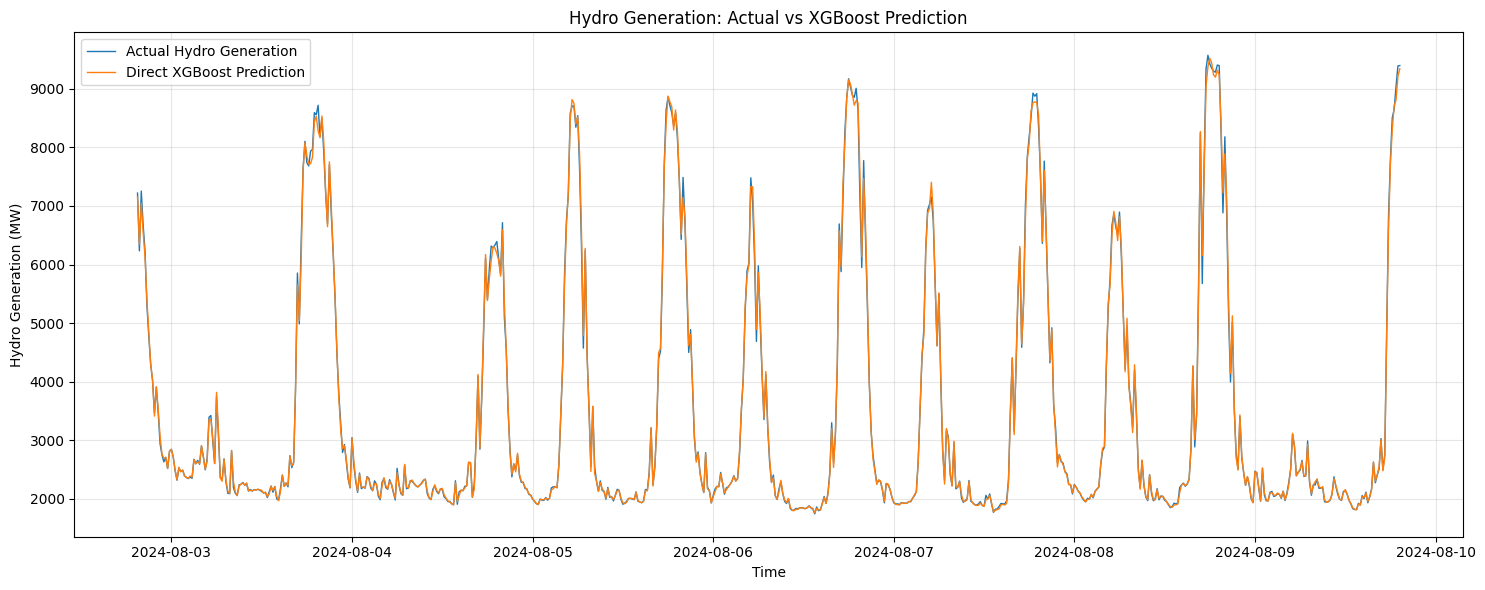

In [121]:
# Plot the first 7 days of the hydro test set
plot_points = 7 * 96

plt.figure(figsize=(15, 6))

plt.plot(
    y_hydro_test.index[:plot_points],
    y_hydro_test.iloc[:plot_points],
    label="Actual Hydro Generation",
    linewidth=1
)

plt.plot(
    y_hydro_test.index[:plot_points],
    hydro_xgb_predictions[:plot_points],
    label="Direct XGBoost Prediction",
    linewidth=1
)

plt.title("Hydro Generation: Actual vs XGBoost Prediction")
plt.xlabel("Time")
plt.ylabel("Hydro Generation (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Load Delta Forecasting

A delta-based XGBoost model is evaluated for electricity-load forecasting.

Instead of directly predicting the next 15-minute load, the model predicts
the change in load from the most recently observed value:

    Load Delta = Load(t+15) - Load(t)

The predicted change is then added to the latest observed load to reconstruct
the 15-minute-ahead forecast.

In [122]:
# Create a copy of the load modeling dataset
df_load_delta = df_model.copy()

# Predict the change in electricity load
df_load_delta["load_delta"] = (
    df_load_delta[target_column]
    - df_load_delta["lag_15min"]
)

print("Load delta statistics:")
print(df_load_delta["load_delta"].describe())

Load delta statistics:
count    379962.000000
mean         -0.216525
std         733.018847
min      -15254.860960
25%        -470.150000
50%         -82.390000
75%         366.157500
max       11281.340000
Name: load_delta, dtype: float64


In [123]:
# Define predictors
load_delta_predictor_columns = [
    col for col in df_load_delta.columns
    if col not in [target_column, "load_delta"]
]

X_load_delta = df_load_delta[load_delta_predictor_columns]
y_load_delta = df_load_delta["load_delta"]

# Chronological 70/15/15 split
n = len(df_load_delta)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_load_delta_train = X_load_delta.iloc[:train_end]
y_load_delta_train = y_load_delta.iloc[:train_end]

X_load_delta_validation = X_load_delta.iloc[train_end:validation_end]
y_load_delta_validation = y_load_delta.iloc[train_end:validation_end]

X_load_delta_test = X_load_delta.iloc[validation_end:]
y_load_delta_test = y_load_delta.iloc[validation_end:]

print("Training:", X_load_delta_train.shape)
print("Validation:", X_load_delta_validation.shape)
print("Test:", X_load_delta_test.shape)

Training: (265973, 59)
Validation: (56994, 59)
Test: (56995, 59)


In [124]:
load_delta_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

load_delta_xgb_model.fit(
    X_load_delta_train,
    y_load_delta_train,
    eval_set=[(X_load_delta_validation, y_load_delta_validation)],
    verbose=False
)

print("Load delta XGBoost model training completed.")

Load delta XGBoost model training completed.


In [125]:
# Predict load change
load_delta_predictions = load_delta_xgb_model.predict(
    X_load_delta_test
)

# Reconstruct absolute load forecast
load_delta_xgb_predictions = (
    X_load_delta_test["lag_15min"].values
    + load_delta_predictions
)

# Evaluate
load_delta_xgb_mae = mean_absolute_error(
    y_test,
    load_delta_xgb_predictions
)

load_delta_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        load_delta_xgb_predictions
    )
)

print("Load Delta XGBoost Results")
print("-" * 40)
print(f"Test MAE:  {load_delta_xgb_mae:.2f} MW")
print(f"Test RMSE: {load_delta_xgb_rmse:.2f} MW")

Load Delta XGBoost Results
----------------------------------------
Test MAE:  258.44 MW
Test RMSE: 364.16 MW


## Wind Delta Forecasting

A delta-based XGBoost model is evaluated for total wind-generation
forecasting.

Instead of directly predicting the next 15-minute wind generation,
the model predicts the change from the most recently observed value.

The predicted change is then added to the latest observed wind generation
to reconstruct the 15-minute-ahead forecast.

In [126]:
# Create a copy of the wind modeling dataset
df_wind_delta = df_wind_model.copy()

# Predict the change in total wind generation
df_wind_delta["wind_delta"] = (
    df_wind_delta[wind_target]
    - df_wind_delta["wind_lag_15min"]
)

print("Wind delta statistics:")
print(df_wind_delta["wind_delta"].describe())

Wind delta statistics:
count    379586.000000
mean         -0.140600
std         317.885306
min       -3661.130000
25%        -158.750000
50%          -3.880000
75%         151.780000
max        3866.081472
Name: wind_delta, dtype: float64


In [127]:
# Define predictors
wind_delta_predictor_columns = [
    col for col in df_wind_delta.columns
    if col not in [wind_target, "wind_delta"]
]

X_wind_delta = df_wind_delta[wind_delta_predictor_columns]
y_wind_delta = df_wind_delta["wind_delta"]

# Chronological 70/15/15 split
n = len(df_wind_delta)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_wind_delta_train = X_wind_delta.iloc[:train_end]
y_wind_delta_train = y_wind_delta.iloc[:train_end]

X_wind_delta_validation = X_wind_delta.iloc[train_end:validation_end]
y_wind_delta_validation = y_wind_delta.iloc[train_end:validation_end]

X_wind_delta_test = X_wind_delta.iloc[validation_end:]
y_wind_delta_test = y_wind_delta.iloc[validation_end:]

print("Training:", X_wind_delta_train.shape)
print("Validation:", X_wind_delta_validation.shape)
print("Test:", X_wind_delta_test.shape)

Training: (265710, 67)
Validation: (56938, 67)
Test: (56938, 67)


In [128]:
wind_delta_xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

wind_delta_xgb_model.fit(
    X_wind_delta_train,
    y_wind_delta_train,
    eval_set=[(X_wind_delta_validation, y_wind_delta_validation)],
    verbose=False
)

print("Wind delta XGBoost model training completed.")

Wind delta XGBoost model training completed.


In [129]:
# Predict wind-generation change
wind_delta_predictions = wind_delta_xgb_model.predict(
    X_wind_delta_test
)

# Reconstruct absolute wind-generation forecast
wind_delta_xgb_predictions = (
    X_wind_delta_test["wind_lag_15min"].values
    + wind_delta_predictions
)

# Evaluate
wind_delta_xgb_mae = mean_absolute_error(
    y_wind_test,
    wind_delta_xgb_predictions
)

wind_delta_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_wind_test,
        wind_delta_xgb_predictions
    )
)

print("Wind Delta XGBoost Results")
print("-" * 40)
print(f"Test MAE:  {wind_delta_xgb_mae:.2f} MW")
print(f"Test RMSE: {wind_delta_xgb_rmse:.2f} MW")

Wind Delta XGBoost Results
----------------------------------------
Test MAE:  147.65 MW
Test RMSE: 219.96 MW


In [130]:
load_model_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Direct XGBoost",
        "Delta XGBoost"
    ],
    "Test MAE (MW)": [
        519.34,
        278.23,
        load_delta_xgb_mae
    ],
    "Test RMSE (MW)": [
        690.23,
        387.99,
        load_delta_xgb_rmse
    ]
})

print(load_model_comparison.to_string(index=False))

load_delta_improvement = (
    (519.34 - load_delta_xgb_mae)
    / 519.34
    * 100
)

print(
    f"\nDelta XGBoost MAE improvement over persistence: "
    f"{load_delta_improvement:.2f}%"
)

         Model  Test MAE (MW)  Test RMSE (MW)
   Persistence     519.340000      690.230000
Direct XGBoost     278.230000      387.990000
 Delta XGBoost     258.442105      364.158395

Delta XGBoost MAE improvement over persistence: 50.24%


In [131]:
wind_model_comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Direct XGBoost",
        "Delta XGBoost"
    ],
    "Test MAE (MW)": [
        wind_baseline_mae,
        wind_xgb_mae,
        wind_delta_xgb_mae
    ],
    "Test RMSE (MW)": [
        wind_baseline_rmse,
        wind_xgb_rmse,
        wind_delta_xgb_rmse
    ]
})

print(wind_model_comparison.to_string(index=False))

wind_delta_improvement = (
    (wind_baseline_mae - wind_delta_xgb_mae)
    / wind_baseline_mae
    * 100
)

print(
    f"\nDelta XGBoost MAE improvement over persistence: "
    f"{wind_delta_improvement:.2f}%"
)

         Model  Test MAE (MW)  Test RMSE (MW)
   Persistence     274.893119      389.107431
Direct XGBoost     157.268506      333.819981
 Delta XGBoost     147.650433      219.955849

Delta XGBoost MAE improvement over persistence: 46.29%


In [132]:
load_delta_feature_importance = pd.DataFrame({
    "Feature": X_load_delta_train.columns,
    "Importance": load_delta_xgb_model.feature_importances_
})

load_delta_feature_importance = (
    load_delta_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Load Delta Forecasting Features:")
print(
    load_delta_feature_importance
    .head(15)
    .to_string(index=False)
)

Top 15 Load Delta Forecasting Features:
                                                     Feature  Importance
                                                        hour    0.362457
                                                  is_weekend    0.145983
                                                 day_of_week    0.098011
                          generation_import_Generation_Solar    0.048146
                      intraday_wind_and_solar_forecast_Solar    0.040930
                                                      minute    0.029836
                                                   lag_15min    0.028964
                                                   lag_1hour    0.026750
                          generation_Solar_Actual Aggregated    0.024625
                                                       month    0.023873
                                            rolling_std_1day    0.014250
                                          rolling_mean_1hour    0.012427
generation_

In [133]:
wind_delta_feature_importance = pd.DataFrame({
    "Feature": X_wind_delta_train.columns,
    "Importance": wind_delta_xgb_model.feature_importances_
})

wind_delta_feature_importance = (
    wind_delta_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Wind Delta Forecasting Features:")
print(
    wind_delta_feature_importance
    .head(15)
    .to_string(index=False)
)

Top 15 Wind Delta Forecasting Features:
                                   Feature  Importance
                                      hour    0.081641
                            wind_lag_1hour    0.066851
        generation_import_Generation_Solar    0.058915
                    wind_rolling_mean_1day    0.057004
 generation_import_Generation_Wind Onshore    0.053604
 generation_Wind Onshore_Actual Aggregated    0.036995
        generation_Solar_Actual Aggregated    0.032060
generation_Wind Offshore_Actual Aggregated    0.029478
                               day_of_year    0.027677
    intraday_wind_and_solar_forecast_Solar    0.025005
                     wind_rolling_std_1day    0.024700
generation_import_Generation_Wind Offshore    0.023212
                   wind_rolling_mean_1hour    0.019000
                             wind_lag_1day    0.018657
                            wind_lag_15min    0.018398


## Load Generation: Actual vs Delta XGBoost Prediction

The following visualization compares actual electricity load with the
15-minute-ahead forecasts produced by the selected Delta XGBoost model.
The first seven days of the test period are shown.

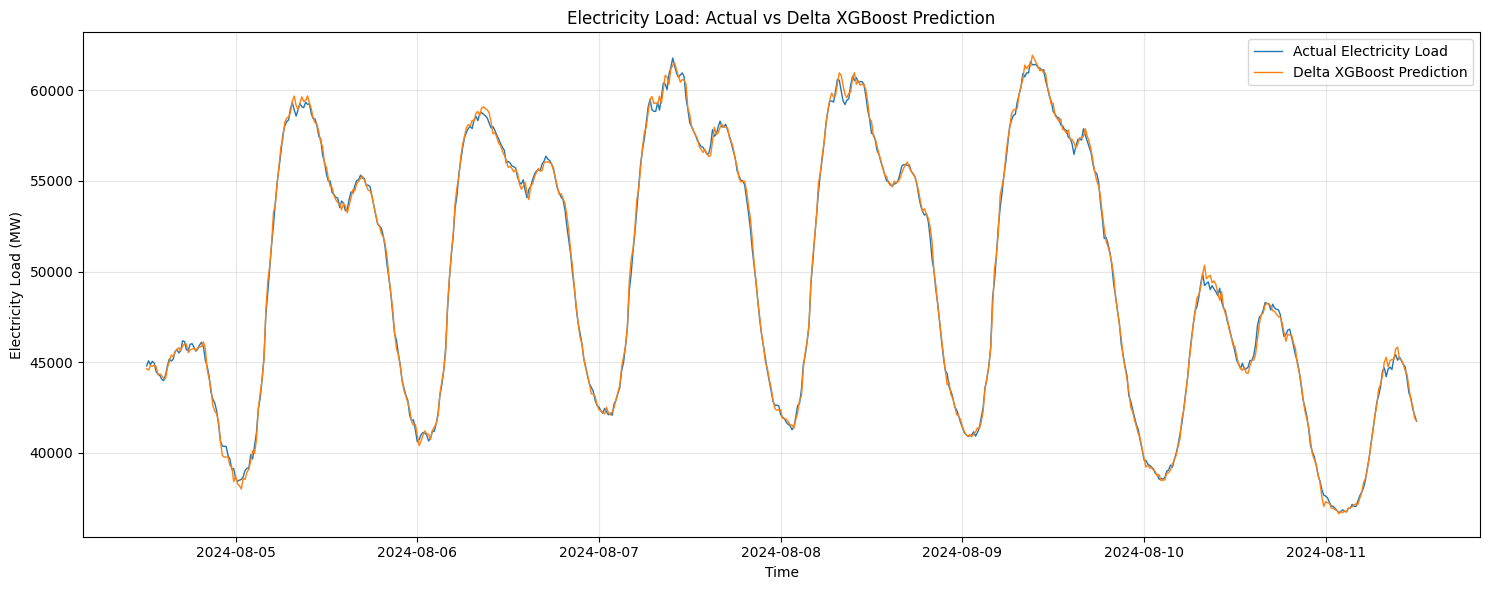

In [134]:
# Plot the first 7 days of the load test set
plot_points = 7 * 96

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index[:plot_points],
    y_test.iloc[:plot_points],
    label="Actual Electricity Load",
    linewidth=1
)

plt.plot(
    y_test.index[:plot_points],
    load_delta_xgb_predictions[:plot_points],
    label="Delta XGBoost Prediction",
    linewidth=1
)

plt.title("Electricity Load: Actual vs Delta XGBoost Prediction")
plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Wind Generation: Actual vs Delta XGBoost Prediction

The following visualization compares actual wind generation with the
15-minute-ahead forecasts produced by the selected Delta XGBoost model.
The first seven days of the test period are shown.

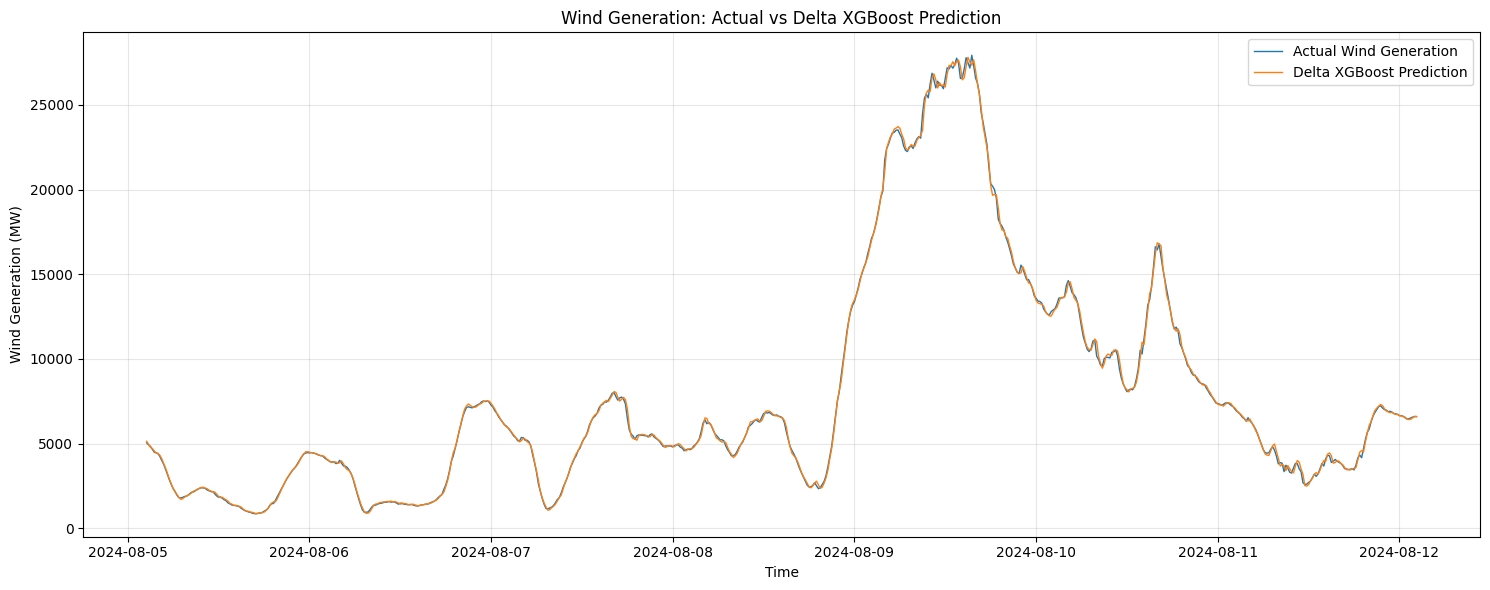

In [135]:
# Plot the first 7 days of the wind test set
plot_points = 7 * 96

plt.figure(figsize=(15, 6))

plt.plot(
    y_wind_test.index[:plot_points],
    y_wind_test.iloc[:plot_points],
    label="Actual Wind Generation",
    linewidth=1
)

plt.plot(
    y_wind_test.index[:plot_points],
    wind_delta_xgb_predictions[:plot_points],
    label="Delta XGBoost Prediction",
    linewidth=1
)

plt.title("Wind Generation: Actual vs Delta XGBoost Prediction")
plt.xlabel("Time")
plt.ylabel("Wind Generation (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [139]:
# ============================================================
# GRIDAI -> BACKEND EXPORT
# Run this AFTER all four selected models and predictions exist.
# It exports real notebook test predictions for the frontend.
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd

EXPORT_DIR = Path("backend/data")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _series(values):
    return np.asarray(values, dtype=float)

def _rows(index, actual, predicted, n=168):
    actual = _series(actual)
    predicted = _series(predicted)
    n = min(n, len(actual), len(predicted))
    idx = pd.DatetimeIndex(index)[-n:]
    return [
        {
            "timestamp": str(ts),
            "actual": float(actual[-n+i]),
            "predicted": float(predicted[-n+i])
        }
        for i, ts in enumerate(idx)
    ]

# These are the variables used in the notebook results you just generated.
# If one name differs in your notebook, change ONLY that name here.

targets = {
    "load": {
        "title": "Electricity Load",
        "model": "Delta XGBoost",
        "mae": float(load_delta_xgb_mae),
        "rmse": float(load_delta_xgb_rmse),
        "improvement": float(50.24),
        "actual": y_load_delta_test,
        "predicted": load_delta_predictions,
        "index": X_load_delta_test.index,
        "features": load_delta_feature_importance,
    },
    "wind": {
        "title": "Wind Generation",
        "model": "Delta XGBoost",
        "mae": float(wind_delta_xgb_mae),
        "rmse": float(wind_delta_xgb_rmse),
        "improvement": float(46.29),
        "actual": y_wind_delta_test,
        "predicted": wind_delta_predictions,
        "index": X_wind_delta_test.index,
        "features": wind_delta_feature_importance,
    },
    "solar": {
        "title": "Solar Generation",
        "model": "Delta XGBoost",
        "mae": float(solar_delta_xgb_mae),
        "rmse": float(solar_delta_xgb_rmse),
        "improvement": float(80.08),
        "actual": y_solar_delta_test,
        "predicted": solar_delta_predictions,
        "index": X_solar_delta_test.index,
        "features": solar_delta_feature_importance,
    },
    "hydro": {
        "title": "Hydro Generation",
        "model": "Direct XGBoost",
        "mae": float(hydro_xgb_mae),
        "rmse": float(hydro_xgb_rmse),
        "improvement": float(88.83),
        "actual": y_hydro_test,
        "predicted": hydro_xgb_predictions,
        "index": X_hydro_test.index,
        "features": hydro_feature_importance,
    },
}

out = {"targets": {}}

for key, d in targets.items():
    fi = d["features"]
    if isinstance(fi, pd.DataFrame):
        # Expected columns: Feature/feature and Importance/importance.
        cols = {c.lower(): c for c in fi.columns}
        fc = cols.get("feature", list(fi.columns)[0])
        ic = cols.get("importance", list(fi.columns)[1])
        features = [
            {"feature": str(r[fc]), "importance": float(r[ic])}
            for _, r in fi.head(15).iterrows()
        ]
    else:
        # If feature importance is a dict/Series.
        s = pd.Series(fi).sort_values(ascending=False)
        features = [{"feature": str(k), "importance": float(v)} for k, v in s.head(15).items()]

    rows = _rows(d["index"], d["actual"], d["predicted"], n=168)

    out["targets"][key] = {
        "title": d["title"],
        "model": d["model"],
        "mae": d["mae"],
        "rmse": d["rmse"],
        "improvement": d["improvement"],
        "latest": rows[-1],
        "series": rows,
        "features": features,
    }

Path("backend/data/gridai_results.json").write_text(
    json.dumps(out, indent=2),
    encoding="utf-8"
)

print("Export complete.")
print("Created: backend/data/gridai_results.json")
print("The frontend can now display real test-set predictions through FastAPI.")


Export complete.
Created: backend/data/gridai_results.json
The frontend can now display real test-set predictions through FastAPI.
